# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

In [64]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

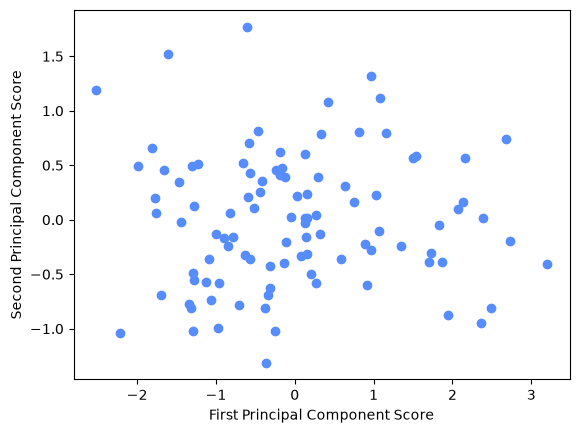

In [65]:
np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

Advantages: 
- It compresses 3 variables into 2 while keeping ~99% of the variance (80%+19%)
- It correctly isolates the one non-redundant piece of information (ser3's deviation) as its own axis — an outlier that isn't obvious from any single histogram.

Disadvantages: 
- The axes are abstract linear combinations, not directly interpretable without going back to the loadings
- It silently discards the ser1-vs-ser2 distinction (into PC3) since that information carries almost no variance
- It can't show you the actual functional relationships (the tight linear ser1-ser2 relationship, the looser ser1/ser2-ser3 relationship) that the pairplot makes immediately visual.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## All Datasets

In [66]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

import warnings
warnings.filterwarnings('ignore')

In [67]:
pd.set_option('display.max_columns', 100)

## Dataset 1: Malware

### Setup

In [68]:
# Load and combine the datasets
files = [
    "malware_benign_1.csv",
    "malware_benign_2.csv",
    "malware_benign_3.csv",
    "malware_benign_4.csv",
    "malware_benign_5.csv",
    "malware_benign_6.csv",
    "malware_benign_7.csv",
    "malware_benign_8.csv",
    "malware_benign_9.csv",
    "malware_benign_10.csv",
    "malware_benign_11.csv",
    "malware_benign_12.csv",
    "malware_benign_13.csv",
    "malware_benign_14.csv",
    "malware_benign_15.csv",
    "ransomware_wannalocker_1.csv",
    "ransomware_wannalocker_2.csv",
    "ransomware_wannalocker_3.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

ransomware_df = pd.concat(dfs, ignore_index=True)
print(ransomware_df.shape)

(18231, 85)


In [69]:
# Print the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [70]:
# Normalize the Label column
print("Before:", ransomware_df['Label'].unique())

ransomware_df['Label'] = np.where(ransomware_df['Label'].str.strip().str.upper() == 'BENIGN', 0, 1)

print("After:", ransomware_df['Label'].unique())
ransomware_df['Label'].value_counts()

Before: <StringArray>
['BENIGN', 'RANSOMWARE_WANNALOCKER']
Length: 2, dtype: str
After: [0 1]


Label
1    10161
0     8070
Name: count, dtype: int64

In [71]:
# Drop duplicate rows
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 18231 rows remaining


In [72]:
# Drop null & NaN values
before = len(ransomware_df)
ransomware_df = ransomware_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(ransomware_df)} rows with null/NaN values -> {len(ransomware_df)} rows remaining")

Dropped 0 rows with null/NaN values -> 18231 rows remaining


In [73]:
# Drop negative values
before = len(ransomware_df)
numeric_cols = ransomware_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_forward / Init_Win_bytes_backward use -1 as a sentinel meaning
# "no forward/backward-direction window observed" (not invalid data), so they are
# excluded from the negative-value check.
negative_check_cols = numeric_cols.drop(['Init_Win_bytes_forward', 'Init_Win_bytes_backward'])

negative_mask = (ransomware_df[negative_check_cols] < 0).any(axis=1)
ransomware_df = ransomware_df[~negative_mask]
print(f"Dropped {before - len(ransomware_df)} rows containing negative values (excluding Init_Win_bytes_forward/backward) -> {len(ransomware_df)} rows remaining")

Dropped 27 rows containing negative values (excluding Init_Win_bytes_forward/backward) -> 18204 rows remaining


In [74]:
# Drop non-numeric columns
non_numeric_cols = ransomware_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

ransomware_df = ransomware_df.drop(columns=non_numeric_cols)
print(ransomware_df.shape)

Dropping non-numeric columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
(18204, 81)


In [75]:
# Drop perfectly correlated columns
corr_matrix = ransomware_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

ransomware_df = ransomware_df.drop(columns=perfectly_correlated)
print(ransomware_df.shape)

Dropping 8 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(18204, 73)


In [76]:
# Drop duplicate rows (post feature engineering)
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 18204 rows remaining


In [77]:
# Print cleaned DataFrame
ransomware_df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,51023,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,1,0,0,0,0,1.0,403.642857,0,0,0,0,0,0,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,51023,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34259,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,55509,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,0,0,1,0,0,0,1.0,31.000000,0,0,0,0,0,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,44852,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,1,0,0,0,0,1.0,124.615385,0,0,0,0,0,0,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [78]:
# Sanity check
print("Any nulls left:", ransomware_df.isnull().values.any())
print("Any negatives left:", (ransomware_df < 0).values.any())
print("Any duplicate rows left:", ransomware_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in ransomware_df.dtypes))
print("\nFinal shape:", ransomware_df.shape)
print("\nLabel counts:")
print(ransomware_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (18204, 73)

Label counts:
Label
1    10159
0     8045
Name: count, dtype: int64


In [79]:
# Export cleaned data to CSV
ransomware_df.to_csv("malware_combined_clean.csv", index=False)
print("Saved malware_combined_clean.csv")

Saved malware_combined_clean.csv


### Heatmaps

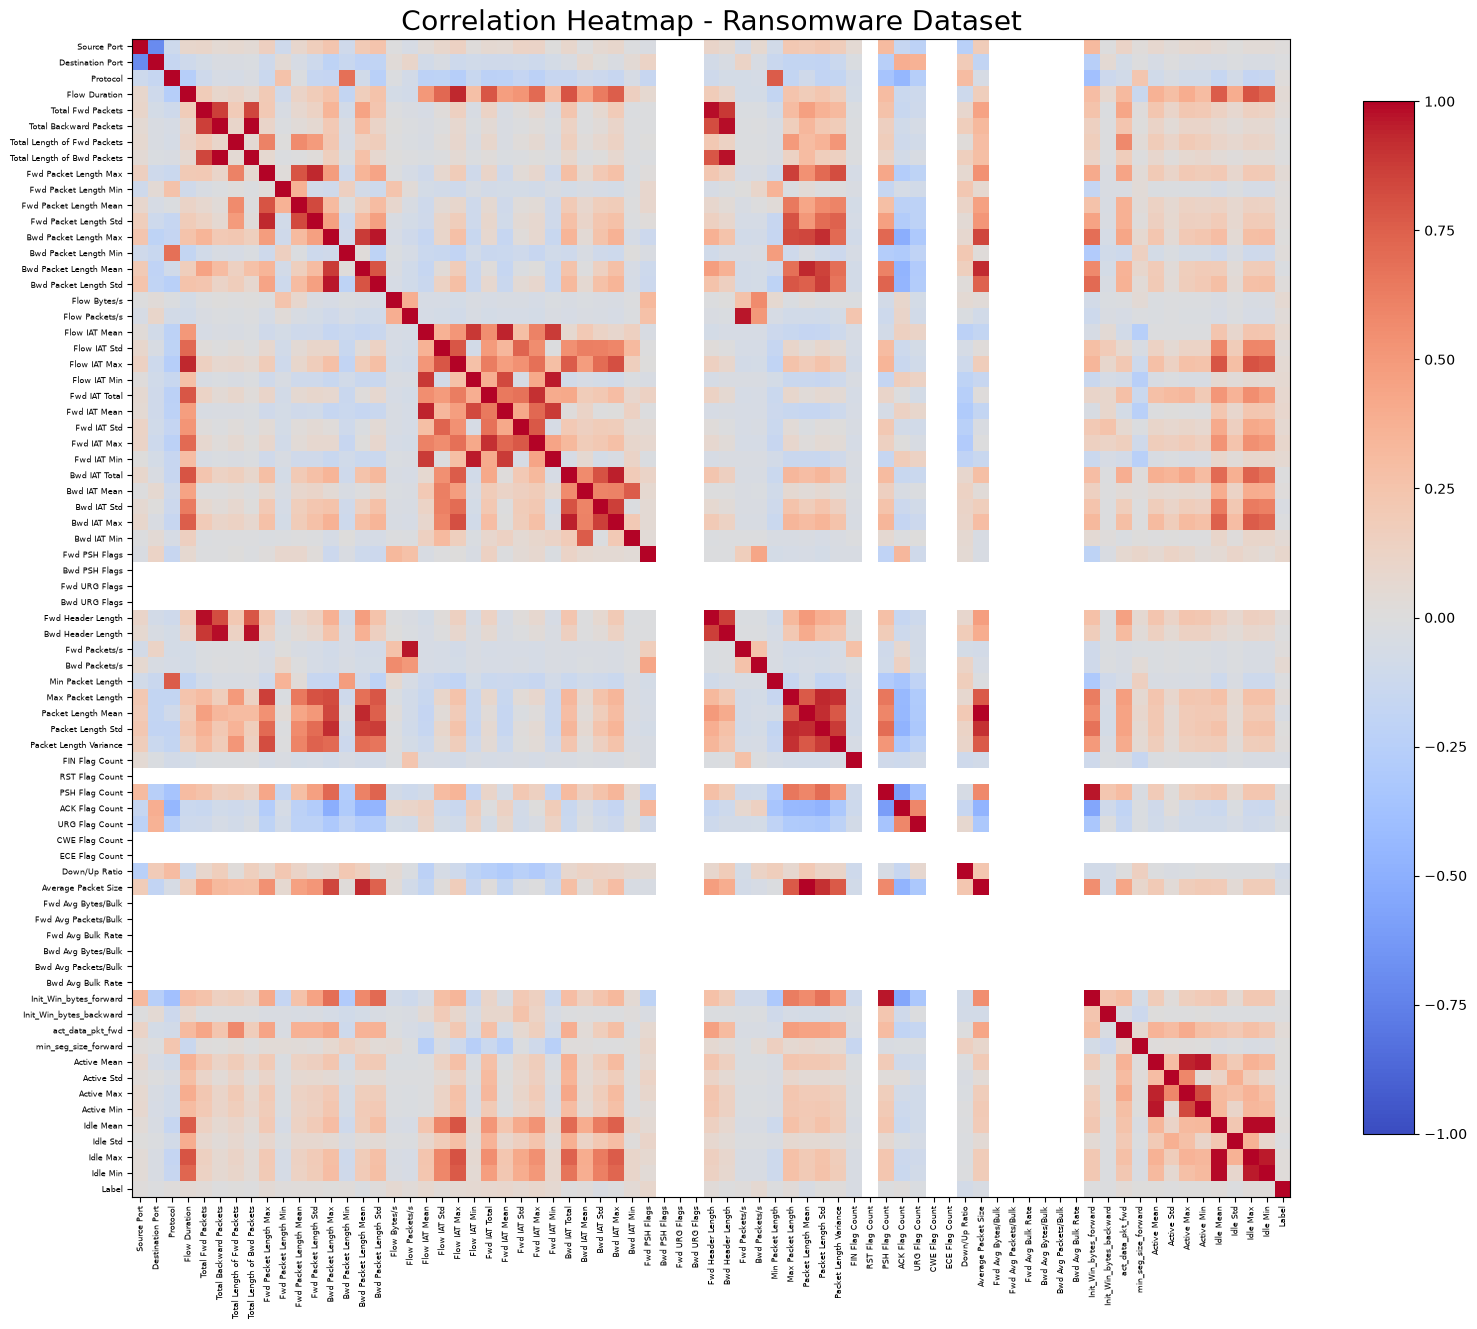

In [80]:
# Draw heatmaps

# Correlation
corr = ransomware_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Heatmap - Ransomware Dataset", fontsize=20)
plt.tight_layout()
plt.show()

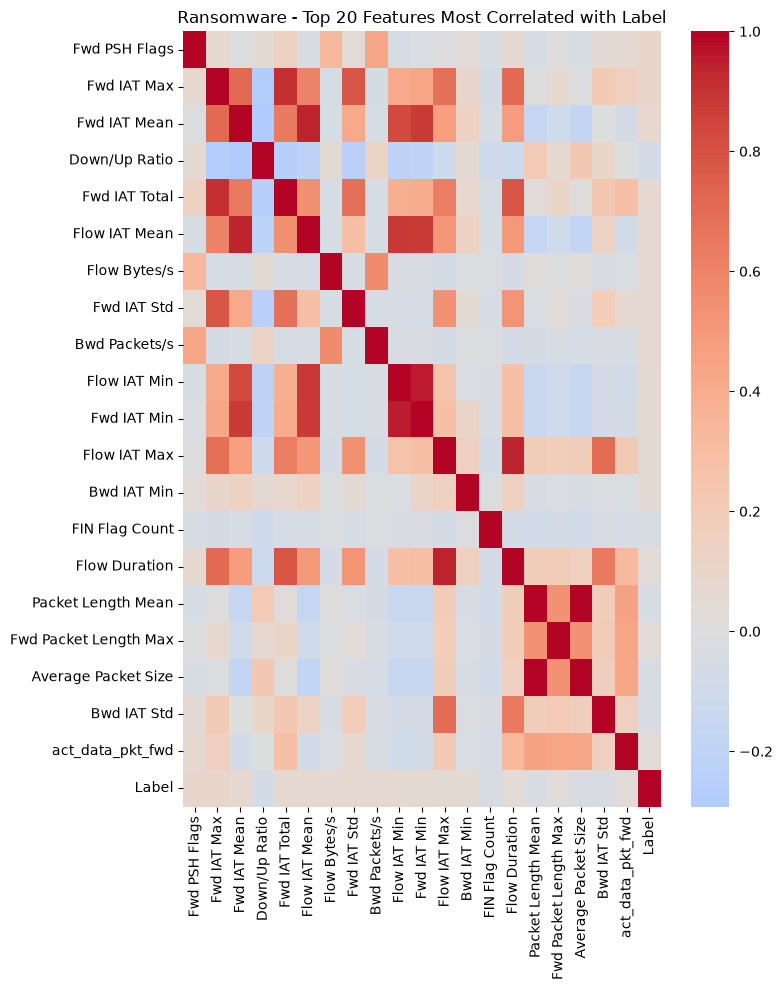

Fwd PSH Flags            0.092539
Fwd IAT Max              0.089091
Fwd IAT Mean             0.079248
Down/Up Ratio           -0.073840
Fwd IAT Total            0.071005
Flow IAT Mean            0.065408
Flow Bytes/s             0.061760
Fwd IAT Std              0.061274
Bwd Packets/s            0.061130
Flow IAT Min             0.060561
Fwd IAT Min              0.060360
Flow IAT Max             0.047693
Bwd IAT Min              0.046490
FIN Flag Count          -0.044563
Flow Duration            0.043867
Packet Length Mean      -0.042020
Fwd Packet Length Max    0.039820
Average Packet Size     -0.039705
Bwd IAT Std             -0.035986
act_data_pkt_fwd         0.035428
Name: Label, dtype: float64

In [82]:
# More readable: top features most correlated with Label
label_corr = corr['Label'].drop('Label').sort_values(key=lambda s: s.abs(), ascending=False)
top_n = 20
top_features = label_corr.head(top_n).index.tolist()

plt.figure(figsize=(8, 10))
sns.heatmap(ransomware_df[top_features + ['Label']].corr(), cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)
plt.title(f"Ransomware - Top {top_n} Features Most Correlated with Label")
plt.tight_layout()
plt.show()

label_corr.head(top_n)

### Principal Component Analysis (PCA)

#### Projection onto first principal component

PC1 alone captures 22.1% of total variance

Per-feature reconstruction error (standardized space, lower = better represented by PC1):
ECE Flag Count          0.0
CWE Flag Count          0.0
Fwd Avg Bytes/Bulk      0.0
Fwd Avg Packets/Bulk    0.0
Bwd Avg Bulk Rate       0.0
Bwd Avg Packets/Bulk    0.0
Bwd Avg Bytes/Bulk      0.0
Fwd Avg Bulk Rate       0.0
RST Flag Count          0.0
Bwd URG Flags           0.0
dtype: float64
...
Fwd IAT Min                0.9978
Down/Up Ratio              0.9982
Fwd PSH Flags              0.9992
Init_Win_bytes_backward    0.9995
min_seg_size_forward       1.0000
dtype: float64


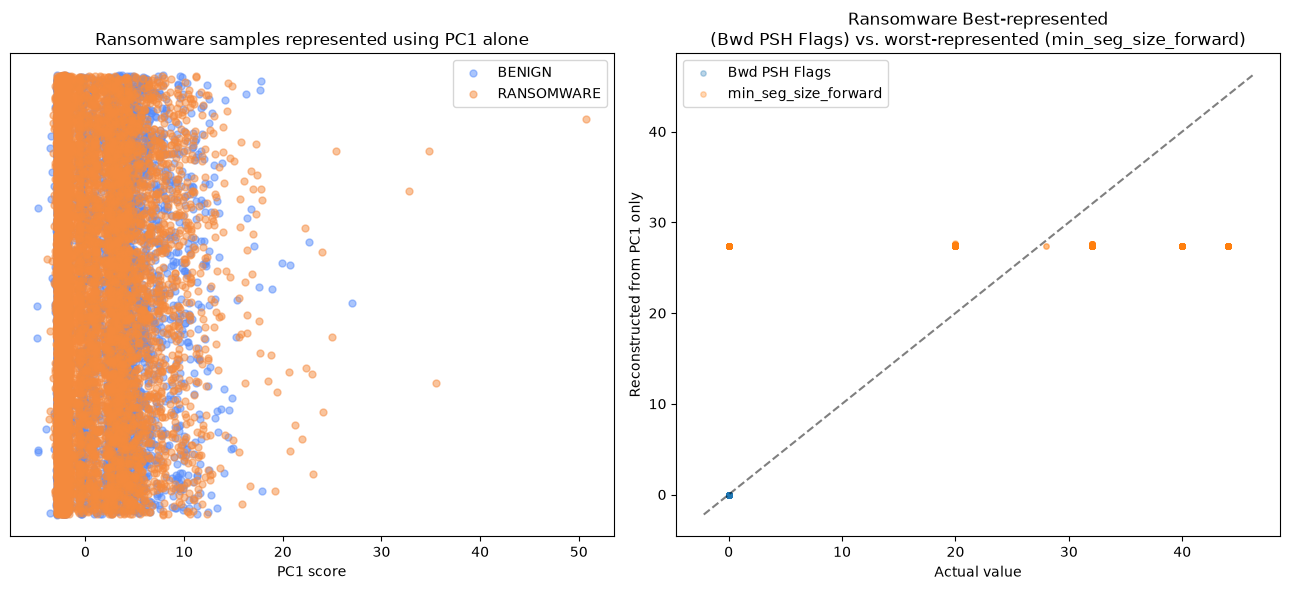

In [83]:
# Principal component analysis

# Representing the data using only PC1
X_pc1 = ransomware_df.drop(columns=['Label'])
y_pc1 = ransomware_df['Label']

scaler_pc1 = StandardScaler()
X_scaled_pc1 = scaler_pc1.fit_transform(X_pc1)

pca_pc1 = PCA()
pca_pc1.fit(X_scaled_pc1)

scores_pc1 = X_scaled_pc1 @ pca_pc1.components_[0]
X_scaled_reconstructed_pc1 = np.outer(scores_pc1, pca_pc1.components_[0])

var_explained_pc1 = pca_pc1.explained_variance_ratio_[0]
print(f"PC1 alone captures {var_explained_pc1:.1%} of total variance")

recon_mse_pc1 = pd.Series(((X_scaled_pc1 - X_scaled_reconstructed_pc1) ** 2).mean(axis=0), index=X_pc1.columns)
print("\nPer-feature reconstruction error (standardized space, lower = better represented by PC1):")
print(recon_mse_pc1.round(4).sort_values().head(10))
print("...")
print(recon_mse_pc1.round(4).sort_values().tail(5))

# Plot
label_names_pc1 = {0: 'BENIGN', 1: 'RANSOMWARE'}
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
rng = np.random.default_rng(0)
for lbl, name in label_names_pc1.items():
    mask = (y_pc1 == lbl).values
    ax.scatter(scores_pc1[mask], rng.uniform(-0.05, 0.05, mask.sum()), label=name, alpha=0.5, s=25)
ax.set_yticks([])
ax.set_xlabel('PC1 score')
ax.set_title('Ransomware samples represented using PC1 alone', fontsize=12)
ax.legend()

X_reconstructed_pc1 = scaler_pc1.inverse_transform(X_scaled_reconstructed_pc1)
best_feat, worst_feat = recon_mse_pc1.idxmin(), recon_mse_pc1.idxmax()
ax2 = axes[1]
for feat, color in [(best_feat, 'tab:blue'), (worst_feat, 'tab:orange')]:
    j = X_pc1.columns.get_loc(feat)
    ax2.scatter(X_pc1[feat], X_reconstructed_pc1[:, j], alpha=0.3, s=15, label=feat, color=color)
lims = ax2.get_xlim()
ax2.plot(lims, lims, 'k--', alpha=0.5)
ax2.set_xlabel('Actual value')
ax2.set_ylabel('Reconstructed from PC1 only')
ax2.set_title(f'Ransomware Best-represented\n({best_feat}) vs. worst-represented ({worst_feat})', fontsize=12)
ax2.legend()
plt.tight_layout()
plt.show()

#### Cumulative variance

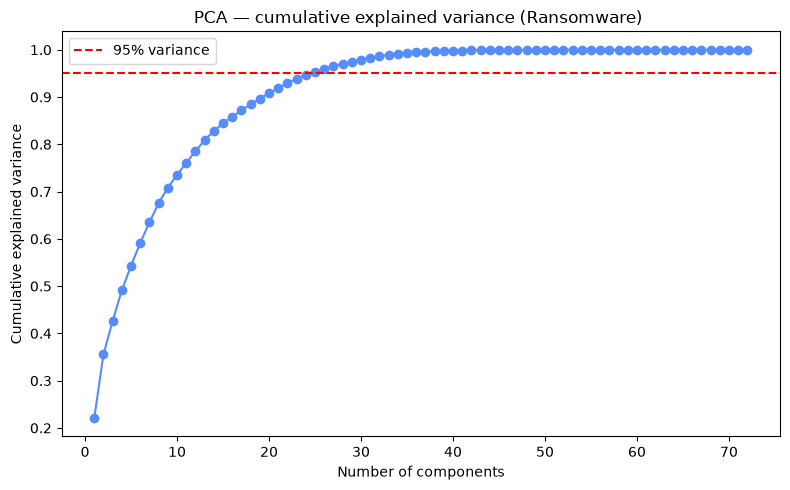

Components needed to explain 95% variance: 25 / 72


In [84]:
# Variance
X = ransomware_df.drop(columns=['Label'])
y = ransomware_df['Label']

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — cumulative explained variance (Ransomware) ')
ax.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Components needed to explain 95% variance: {n_components_95} / {X.shape[1]}")

### Bubbleplots

In [85]:
# Draw bubbleplots

# Setup: Using the first 3 principal components as plot axes (PC1/PC2/PC3), with bubble size mapped to a chosen raw feature and color mapped to `Label`.
pcs = pca.transform(X_scaled)
pc_df = pd.DataFrame(pcs[:, :3], columns=['PC1', 'PC2', 'PC3'], index=X.index)

def scaled_size(series, low=20, high=800):
    s = (series - series.min()) / (series.max() - series.min())
    return s * (high - low) + low

label_colors = y.map({0: 'tab:blue', 1: 'tab:red'})
label_names = {0: 'BENIGN', 1: 'RANSOMWARE'}

In [86]:
# Bubbleplot function
def bubble_plot(x_col, y_col, size_col, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = scaled_size(X[size_col])
    for lbl, color in [(0, 'tab:blue'), (1, 'tab:red')]:
        mask = (y == lbl)
        ax.scatter(pc_df.loc[mask, x_col], pc_df.loc[mask, y_col],
                   s=sizes[mask], c=color, alpha=0.5, edgecolors='k', linewidths=0.3,
                   label=label_names[lbl])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{title}\n(bubble size = {size_col})")
    ax.legend(title='Label', markerscale=0.5)
    plt.tight_layout()
    plt.show()

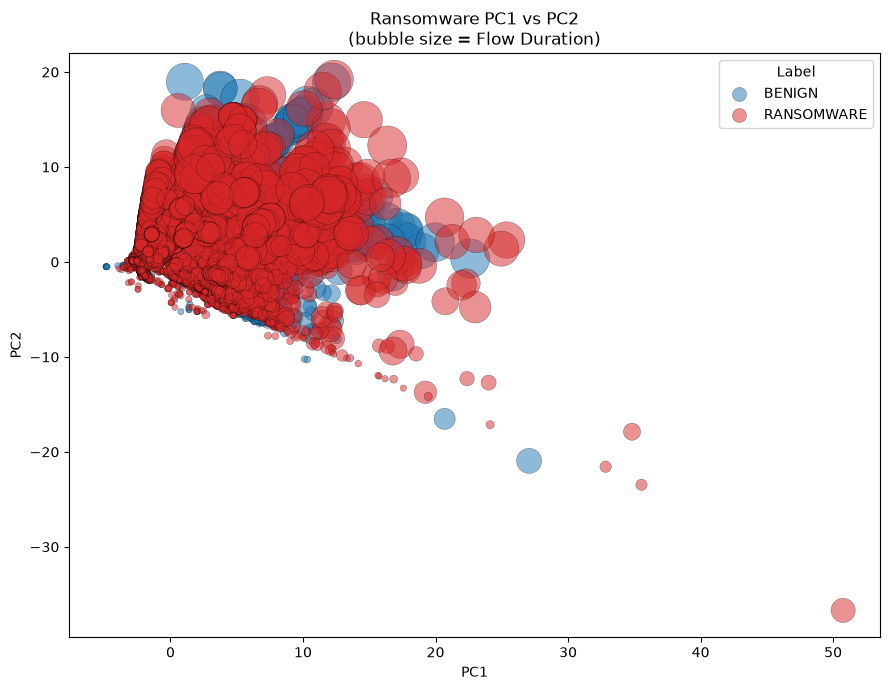

In [87]:
# Bubbleplot for Flow Duration
bubble_plot('PC1', 'PC2', 'Flow Duration', 'Ransomware PC1 vs PC2', 'bubble_pc1_pc2_flowduration.png')

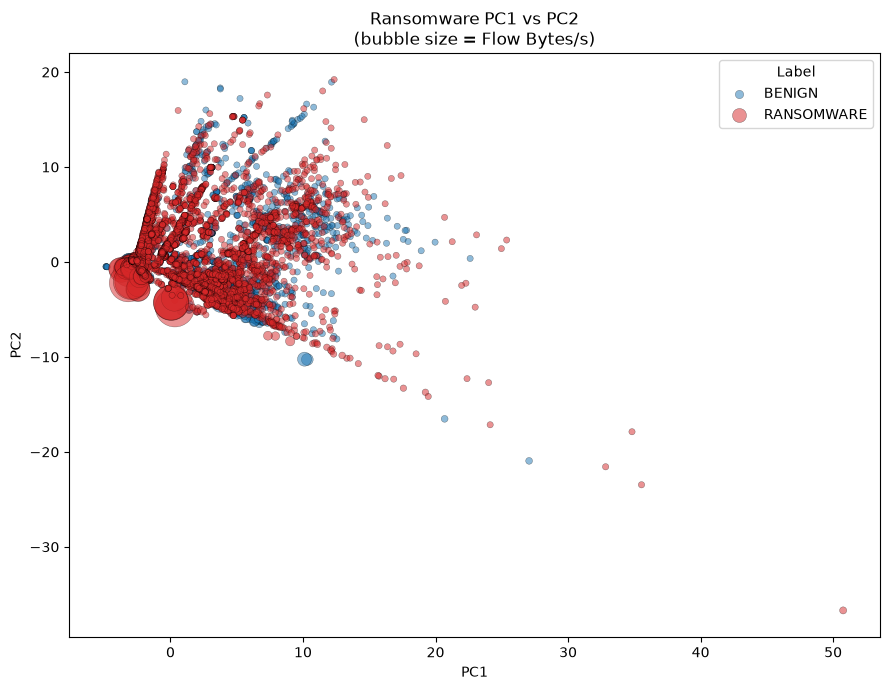

In [88]:
# Bubbleplot for Flow Bytes/s
bubble_plot('PC1', 'PC2', 'Flow Bytes/s', 'Ransomware PC1 vs PC2', 'bubble_pc1_pc2_flowbytes.png')

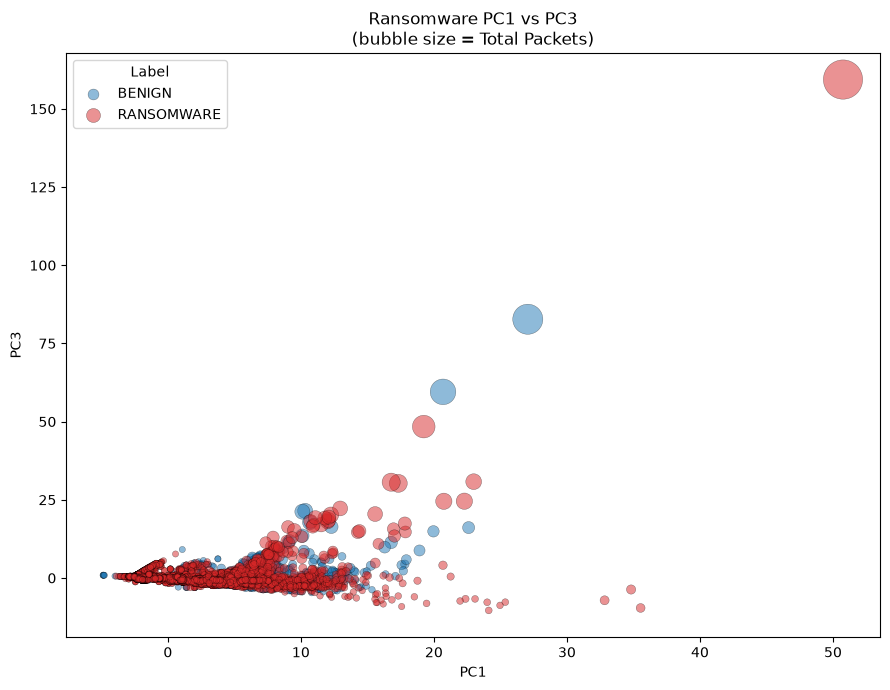

In [89]:
# Bubbleplot for Total Packets
X['Total Packets'] = X['Total Fwd Packets'] + X['Total Backward Packets']
bubble_plot('PC1', 'PC3', 'Total Packets', 'Ransomware PC1 vs PC3', 'bubble_pc1_pc3_totalpackets.png')

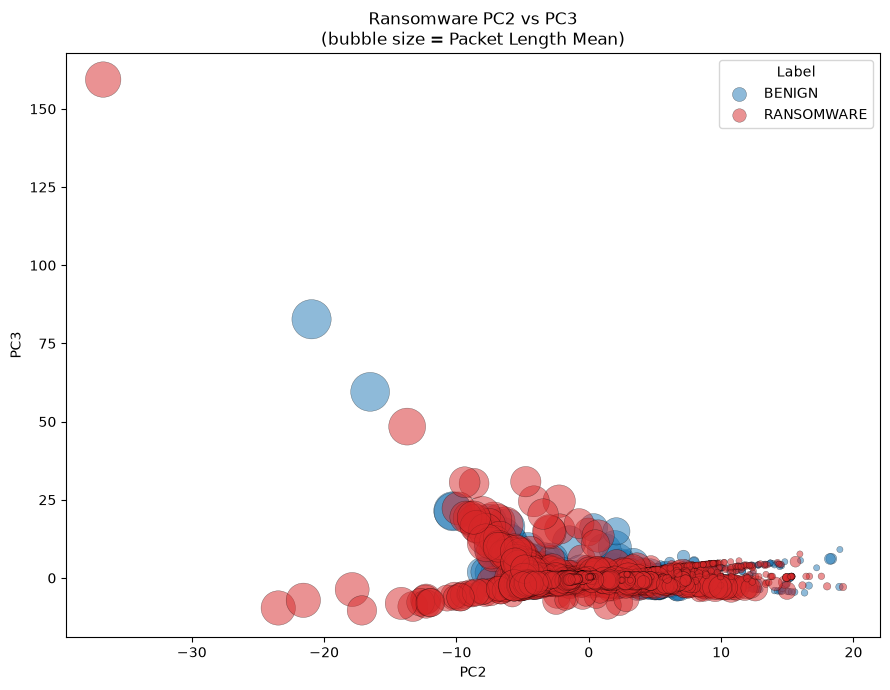

In [90]:
# Bubbleplot for Packet Length Mean
bubble_plot('PC2', 'PC3', 'Packet Length Mean', 'Ransomware PC2 vs PC3', 'bubble_pc2_pc3_packetlen.png')

### Regression

In [91]:
# Regression

# Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (14563, 73) Test shape: (3641, 73)


#### Linear Regression

##### General analysis

In [92]:
# Linear Regression Analysis

# Calculate the R^2 and RMSE
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

print(f"R^2: {r2_score(y_test, y_pred_lin):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_lin) ** 0.5:.4f}")

# Threshold the continuous output at 0.5 to force a class decision
y_pred_lin_class = (y_pred_lin >= 0.5).astype(int)
print(f"Accuracy (0.5 threshold on linear output): {accuracy_score(y_test, y_pred_lin_class):.4f}")

R^2: 0.0478
RMSE: 0.4846
Accuracy (0.5 threshold on linear output): 0.5875


In [93]:
# Create Coefficient DataFrame & print
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.head(15)

,feature,coefficient
42,Packet Length Mean,-0.860650
53,Average Packet Size,0.455820
3,Flow Duration,0.288386
19,Flow IAT Std,-0.258107
68,Idle Mean,-0.252887
14,Bwd Packet Length Mean,0.234832
71,Idle Min,0.221744
18,Flow IAT Mean,0.211524
22,Fwd IAT Total,-0.210540
21,Flow IAT Min,-0.208678


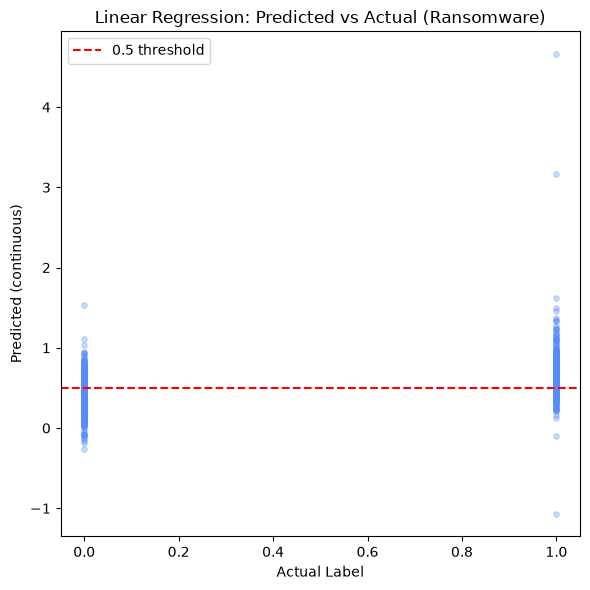

In [94]:
# Plot the Regression
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lin, alpha=0.3, s=15)
ax.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
ax.set_xlabel('Actual Label')
ax.set_ylabel('Predicted (continuous)')
ax.set_title('Linear Regression: Predicted vs Actual (Ransomware)')
ax.legend()
plt.tight_layout()
plt.show()

##### Feature-to-feature analysis

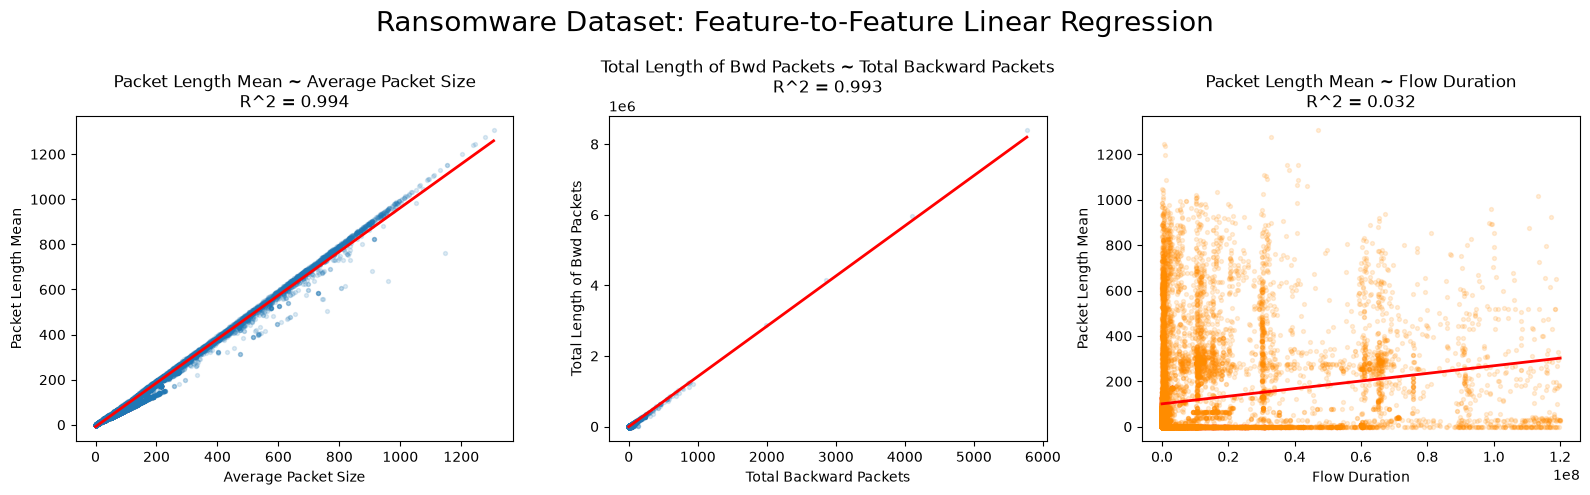

In [95]:
# Feature-to-feature regression plots (Malware)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('Average Packet Size', 'Packet Length Mean', axes[0]),
    ('Total Backward Packets', 'Total Length of Bwd Packets', axes[1]),
    ('Flow Duration', 'Packet Length Mean', axes[2]),  # unrelated, for contrast
]
colors = ['tab:blue', 'tab:blue', 'darkorange']

for (xcol, ycol, ax), color in zip(pairs, colors):
    x = ransomware_df[[xcol]]
    y = ransomware_df[ycol]
    X_tr, X_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=42)
    lr = LinearRegression().fit(X_tr, y_tr)
    r2 = r2_score(y_te, lr.predict(X_te))

    ax.scatter(x, y, alpha=0.15, s=8, color=color)
    xs = np.linspace(x.values.min(), x.values.max(), 100).reshape(-1, 1)
    ax.plot(xs, lr.predict(xs), color='red', linewidth=2)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{ycol} ~ {xcol}\nR^2 = {r2:.3f}", fontsize=12)

plt.suptitle("Ransomware Dataset: Feature-to-Feature Linear Regression", fontsize=20)
plt.tight_layout()
plt.show()

#### Logistic Regression

In [96]:
# Logistic Regression

# Setup
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log):.4f}")
print()
print(classification_report(y_test, y_pred_log, target_names=['BENIGN', 'RANSOMWARE_WANNALOCKER']))

Accuracy: 0.5941
ROC-AUC: 0.6430

                        precision    recall  f1-score   support

                BENIGN       0.57      0.34      0.43      1609
RANSOMWARE_WANNALOCKER       0.60      0.79      0.69      2032

              accuracy                           0.59      3641
             macro avg       0.59      0.57      0.56      3641
          weighted avg       0.59      0.59      0.57      3641



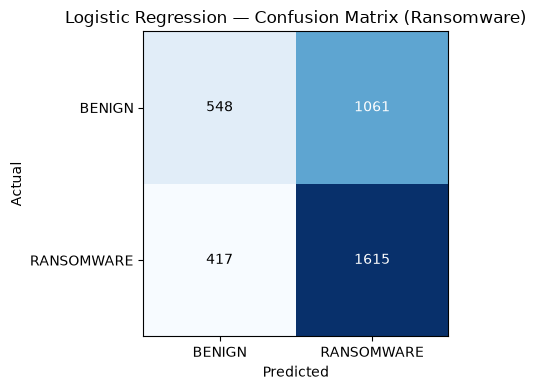

In [97]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['BENIGN', 'RANSOMWARE'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['BENIGN', 'RANSOMWARE'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix (Ransomware)')
plt.tight_layout()
plt.show()

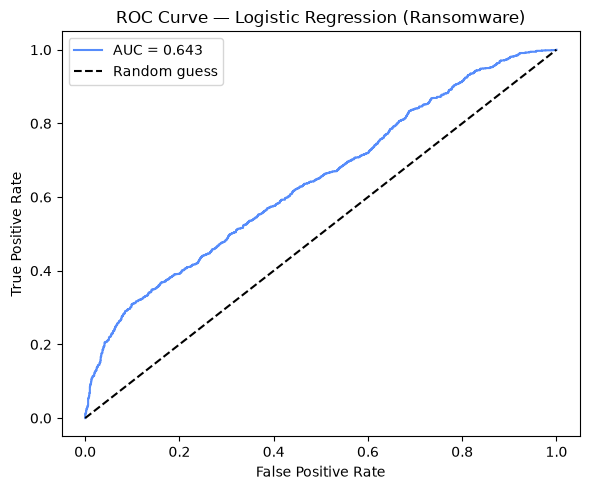

In [98]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_log)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_log):.3f}")
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression (Ransomware)')
ax.legend()
plt.tight_layout()
plt.show()

## Dataset 2: Intrusion

### Setup

In [99]:
# Load the dataset

# Load and combine the datasets
files = [
    "network_traffic_1.csv",
    "network_traffic_2.csv",
    "network_traffic_3.csv",
    "network_traffic_4.csv",
    "network_traffic_5.csv",
    "network_traffic_6.csv",
    "network_traffic_7.csv",
    "network_traffic_8.csv"
]

# First read in as string to accommodate special character in Label column
dfs = []
for f in files:
    df = pd.read_csv(f, encoding="latin1", dtype=str)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

intrusion_df = pd.concat(dfs, ignore_index=True)

# Convert numeric columns to numbers
numeric_candidates = [c for c in intrusion_df.columns if c != 'Label']
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].apply(pd.to_numeric, errors='coerce')

# Infinity parses to np.inf rather than NaN — if you want those treat as missing/dropped like NaN
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].replace([np.inf, -np.inf], np.nan)

print(intrusion_df.shape)

(2830743, 79)


In [100]:
# Print the dataset
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [101]:
# Normalize the Label column

# Where 0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest',
# 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator',
# 12: 'Web Attack - Brute Force', 13: 'Web Attack - Sql Injection', 14: 'Web Attack - XSS'
intrusion_df["Label"] = (
    intrusion_df["Label"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True)
    .str.replace(r"Web Attack.*Sql Injection", "Web Attack - Sql Injection", regex=True)
    .str.replace(r"Web Attack.*XSS", "Web Attack - XSS", regex=True)
)

# Build mapping from all unique label strings to integers
classes = sorted(intrusion_df["Label"].unique())
label_to_int = {label: i for i, label in enumerate(classes)}

with np.printoptions(threshold=np.inf):
    print("Before:", intrusion_df["Label"].astype("string").unique())

    intrusion_df["Label"] = intrusion_df["Label"].map(label_to_int)

    print("After:", intrusion_df["Label"].unique())

print(intrusion_df["Label"].value_counts())

Before: <StringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack - Brute Force',
           'Web Attack - XSS', 'Web Attack - Sql Injection',
                'FTP-Patator',                'SSH-Patator',
              'DoS slowloris',           'DoS Slowhttptest',
                   'DoS Hulk',              'DoS GoldenEye',
                 'Heartbleed']
Length: 15, dtype: string
After: [ 0  2 10  1  9 12 14 13  7 11  6  5  4  3  8]
Label
0     2273097
4      231073
10     158930
2      128027
3       10293
7        7938
11       5897
6        5796
5        5499
1        1966
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [102]:
# Drop duplicate rows
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 308381 duplicate rows -> 2522362 rows remaining


In [103]:
# Drop null & NaN values
before = len(intrusion_df)
intrusion_df = intrusion_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(intrusion_df)} rows with null/NaN values -> {len(intrusion_df)} rows remaining")

Dropped 1564 rows with null/NaN values -> 2520798 rows remaining


In [104]:
# Drop negative values
before = len(intrusion_df)
numeric_cols = intrusion_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_forward / Init_Win_bytes_backward use -1 as a sentinel meaning
# "no forward/backward-direction window observed" (not invalid data), so they are
# excluded from the negative-value check — same fix already applied to ransomware.
negative_check_cols = numeric_cols.drop(['Init_Win_bytes_forward', 'Init_Win_bytes_backward'])

negative_mask = (intrusion_df[negative_check_cols] < 0).any(axis=1)
intrusion_df = intrusion_df[~negative_mask]
print(f"Dropped {before - len(intrusion_df)} rows containing negative values (excluding Init_Win_bytes_forward/backward) -> {len(intrusion_df)} rows remaining")

Dropped 2915 rows containing negative values (excluding Init_Win_bytes_forward/backward) -> 2517883 rows remaining


In [105]:
# Drop non-numeric columns
non_numeric_cols = intrusion_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

intrusion_df = intrusion_df.drop(columns=non_numeric_cols)
print(intrusion_df.shape)

Dropping non-numeric columns: []
(2517883, 79)


In [106]:
# Drop perfectly correlated columns
corr_matrix = intrusion_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

intrusion_df = intrusion_df.drop(columns=perfectly_correlated)
print(intrusion_df.shape)

Dropping 9 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'CWE Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(2517883, 70)


In [108]:
# Drop duplicate rows (post feature engineering)
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 0 duplicate rows -> 2517883 rows remaining


In [109]:
# Print cleaned DataFrame
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,1,0,0,0,9.0,0,0,0,0,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,1,0,0,0,9.0,0,0,0,0,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [110]:
# Sanity check
print("Any nulls left:", intrusion_df.isnull().values.any())
print("Any negatives left:", (intrusion_df < 0).values.any())
print("Any duplicate rows left:", intrusion_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in intrusion_df.dtypes))
print("\nFinal shape:", intrusion_df.shape)
print("\nLabel counts:")
print(intrusion_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (2517883, 70)

Label counts:
Label
0     2092335
4      172688
2      127995
10      90694
3       10281
7        5927
6        5385
5        5228
11       3217
1        1948
12       1470
14        652
9          35
13         21
8           7
Name: count, dtype: int64


In [111]:
# Export cleaned data to CSV
intrusion_df.to_csv("intrusion_newtork_traffic_clean.csv", index=False)
print("Saved intrusion_newtork_traffic_clean.csv")

Saved intrusion_newtork_traffic_clean.csv


### Heatmaps

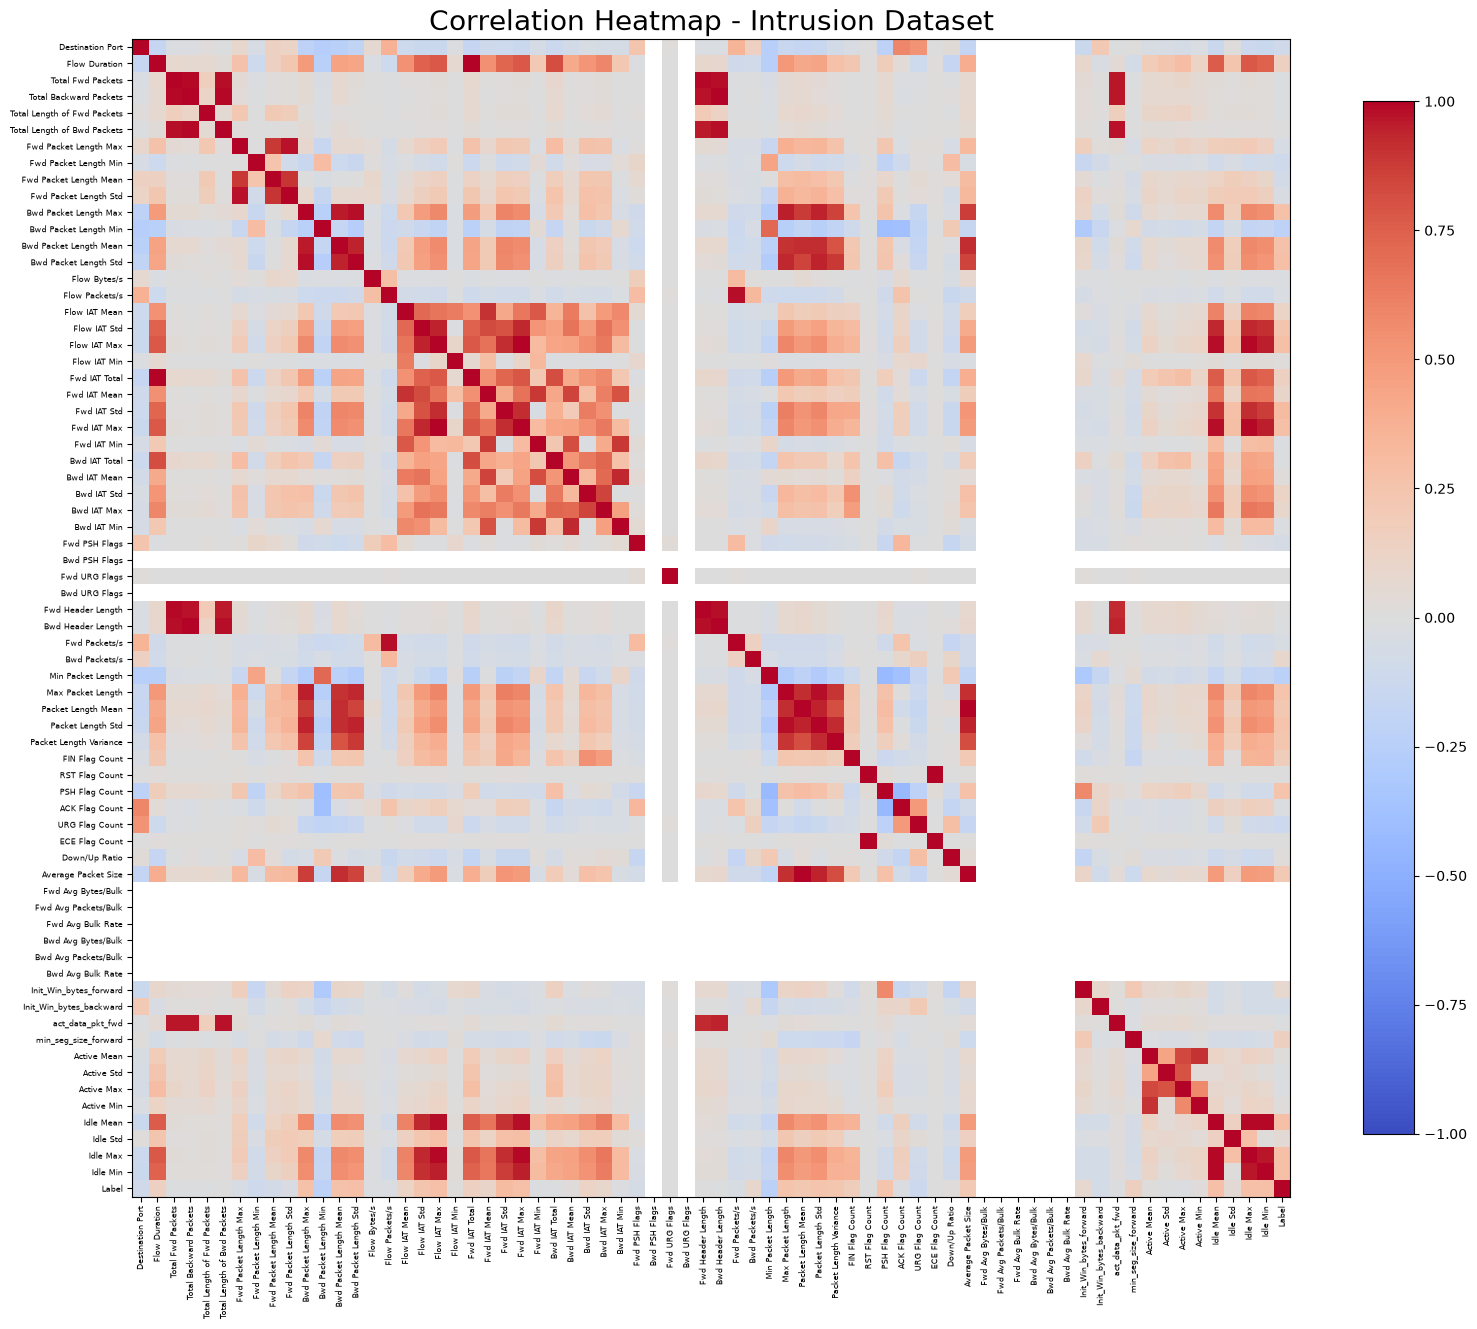

In [112]:
# Draw heatmaps

# Correlation
corr = intrusion_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Heatmap - Intrusion Dataset", fontsize=20)
plt.tight_layout()
plt.show()

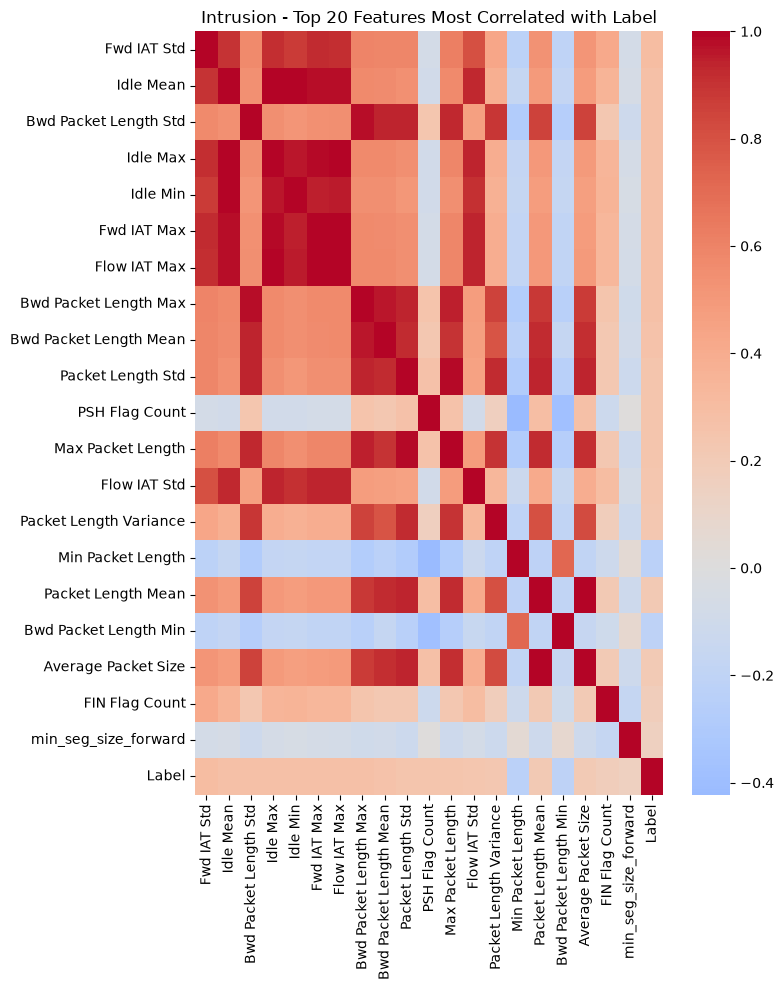

Fwd IAT Std               0.299378
Idle Mean                 0.278571
Bwd Packet Length Std     0.278007
Idle Max                  0.277457
Idle Min                  0.276098
Fwd IAT Max               0.274401
Flow IAT Max              0.273807
Bwd Packet Length Max     0.272325
Bwd Packet Length Mean    0.263201
Packet Length Std         0.248839
PSH Flag Count            0.247874
Max Packet Length         0.246928
Flow IAT Std              0.236158
Packet Length Variance    0.231020
Min Packet Length        -0.230323
Packet Length Mean        0.212290
Bwd Packet Length Min    -0.211830
Average Packet Size       0.208808
FIN Flag Count            0.174339
min_seg_size_forward      0.151223
Name: Label, dtype: float64

In [113]:
# More readable: top features most correlated with Label
label_corr = corr['Label'].drop('Label').sort_values(key=lambda s: s.abs(), ascending=False)
top_n = 20
top_features = label_corr.head(top_n).index.tolist()

plt.figure(figsize=(8, 10))
sns.heatmap(intrusion_df[top_features + ['Label']].corr(), cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)
plt.title(f"Intrusion - Top {top_n} Features Most Correlated with Label")
plt.tight_layout()
plt.show()

label_corr.head(top_n)

### Principal Component Analysis (PCA)

#### Projection onto first principal component

PC1 alone captures 23.7% of total variance

Per-feature reconstruction error (standardized space, lower = better represented by PC1):
Bwd PSH Flags           0.0000
Bwd Avg Bytes/Bulk      0.0000
Fwd Avg Bytes/Bulk      0.0000
Fwd Avg Packets/Bulk    0.0000
Bwd Avg Packets/Bulk    0.0000
Bwd Avg Bulk Rate       0.0000
Fwd Avg Bulk Rate       0.0000
Bwd URG Flags           0.0000
Flow IAT Max            0.1532
Fwd IAT Max             0.1560
dtype: float64
...
ACK Flag Count    0.9984
Flow Bytes/s      0.9997
RST Flag Count    0.9999
ECE Flag Count    0.9999
Fwd URG Flags     1.0000
dtype: float64


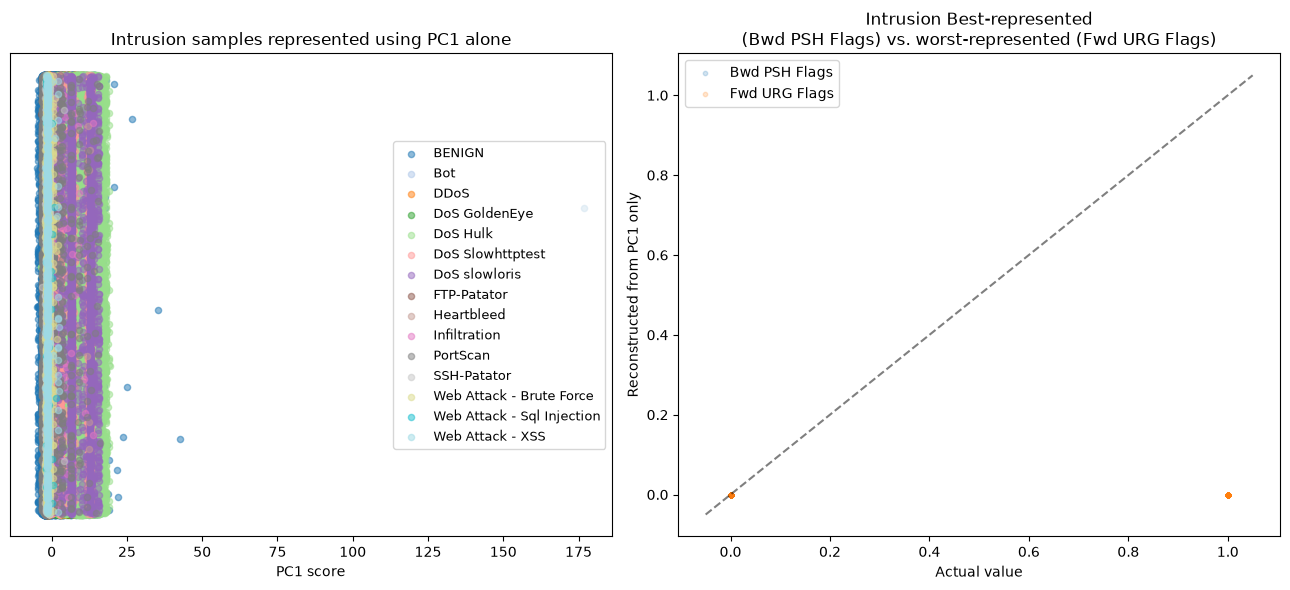

In [114]:
# Principal component analysis

# Representing the data using only PC1
X_pc1 = intrusion_df.drop(columns=['Label'])
y_pc1 = intrusion_df['Label']

scaler_pc1 = StandardScaler()
X_scaled_pc1 = scaler_pc1.fit_transform(X_pc1)

pca_pc1 = PCA()
pca_pc1.fit(X_scaled_pc1)

scores_pc1 = X_scaled_pc1 @ pca_pc1.components_[0]
X_scaled_reconstructed_pc1 = np.outer(scores_pc1, pca_pc1.components_[0])

var_explained_pc1 = pca_pc1.explained_variance_ratio_[0]
print(f"PC1 alone captures {var_explained_pc1:.1%} of total variance")

recon_mse_pc1 = pd.Series(((X_scaled_pc1 - X_scaled_reconstructed_pc1) ** 2).mean(axis=0), index=X_pc1.columns)
print("\nPer-feature reconstruction error (standardized space, lower = better represented by PC1):")
print(recon_mse_pc1.round(4).sort_values().head(10))
print("...")
print(recon_mse_pc1.round(4).sort_values().tail(5))

# Plot
label_names_pc1 = {
    0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk',
    5: 'DoS Slowhttptest', 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed',
    9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator', 12: 'Web Attack - Brute Force',
    13: 'Web Attack - Sql Injection', 14: 'Web Attack - XSS',
}
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
rng = np.random.default_rng(0)
palette_pc1 = plt.cm.tab20(np.linspace(0, 1, len(label_names_pc1)))
for lbl, name in label_names_pc1.items():
    mask = (y_pc1 == lbl).values
    if mask.sum() == 0:
        continue
    ax.scatter(scores_pc1[mask], rng.uniform(-0.05, 0.05, mask.sum()), label=name,
               alpha=0.5, s=20, color=palette_pc1[lbl])
ax.set_yticks([])
ax.set_xlabel('PC1 score')
ax.set_title('Intrusion samples represented using PC1 alone', fontsize=12)
ax.legend(fontsize=9, loc='center right')

X_reconstructed_pc1 = scaler_pc1.inverse_transform(X_scaled_reconstructed_pc1)
best_feat, worst_feat = recon_mse_pc1.idxmin(), recon_mse_pc1.idxmax()
ax2 = axes[1]
for feat, color in [(best_feat, 'tab:blue'), (worst_feat, 'tab:orange')]:
    j = X_pc1.columns.get_loc(feat)
    ax2.scatter(X_pc1[feat], X_reconstructed_pc1[:, j], alpha=0.2, s=10, label=feat, color=color)
lims = ax2.get_xlim()
ax2.plot(lims, lims, 'k--', alpha=0.5)
ax2.set_xlabel('Actual value')
ax2.set_ylabel('Reconstructed from PC1 only')
ax2.set_title(f'Intrusion Best-represented\n({best_feat}) vs. worst-represented ({worst_feat})', fontsize=12)
ax2.legend()
plt.tight_layout()
plt.show()

#### Cumulative variance

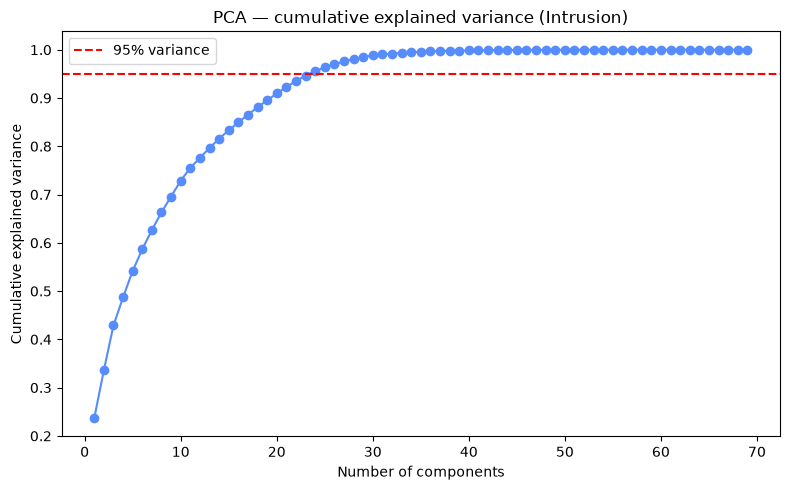

Components needed to explain 95% variance: 24 / 69


In [115]:
# Variance
X = intrusion_df.drop(columns=['Label'])
y = intrusion_df['Label']

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — cumulative explained variance (Intrusion)')
ax.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Components needed to explain 95% variance: {n_components_95} / {X.shape[1]}")

### Bubbleplots

In [116]:
# Setup: Using the first 3 principal components as plot axes (PC1/PC2/PC3), with bubble size mapped to a chosen raw feature and color mapped to `Label`.
pcs = pca.transform(X_scaled)
pc_df = pd.DataFrame(pcs[:, :3], columns=['PC1', 'PC2', 'PC3'], index=X.index)

def scaled_size(series, low=20, high=800):
    s = (series - series.min()) / (series.max() - series.min())
    return s * (high - low) + low

label_names = {
    0: 'BENIGN',
    1: 'Bot',
    2: 'DDoS',
    3: 'DoS GoldenEye',
    4: 'DoS Hulk',
    5: 'DoS Slowhttptest',
    6: 'DoS slowloris',
    7: 'FTP-Patator',
    8: 'Heartbleed',
    9: 'Infiltration',
    10: 'PortScan',
    11: 'SSH-Patator',
    12: 'Web Attack - Brute Force',
    13: 'Web Attack - Sql Injection',
    14: 'Web Attack - XSS',
}

# 15 classes won't fit matplotlib's tab: palette (only 10 named colors), so pull a
# 15-color palette from a qualitative colormap instead.
palette = plt.cm.tab20(np.linspace(0, 1, len(label_names)))
label_colors = {i: palette[i] for i in label_names}

In [117]:
# Bubbleplot function
def bubble_plot(x_col, y_col, size_col, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = scaled_size(X[size_col])
    for lbl, color in label_colors.items():
        mask = (y == lbl)
        ax.scatter(pc_df.loc[mask, x_col], pc_df.loc[mask, y_col],
                   s=sizes[mask], c=color, alpha=0.5, edgecolors='k', linewidths=0.3,
                   label=label_names[lbl])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{title}\n(bubble size = {size_col})")
    ax.legend(title='Label', markerscale=0.5, loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

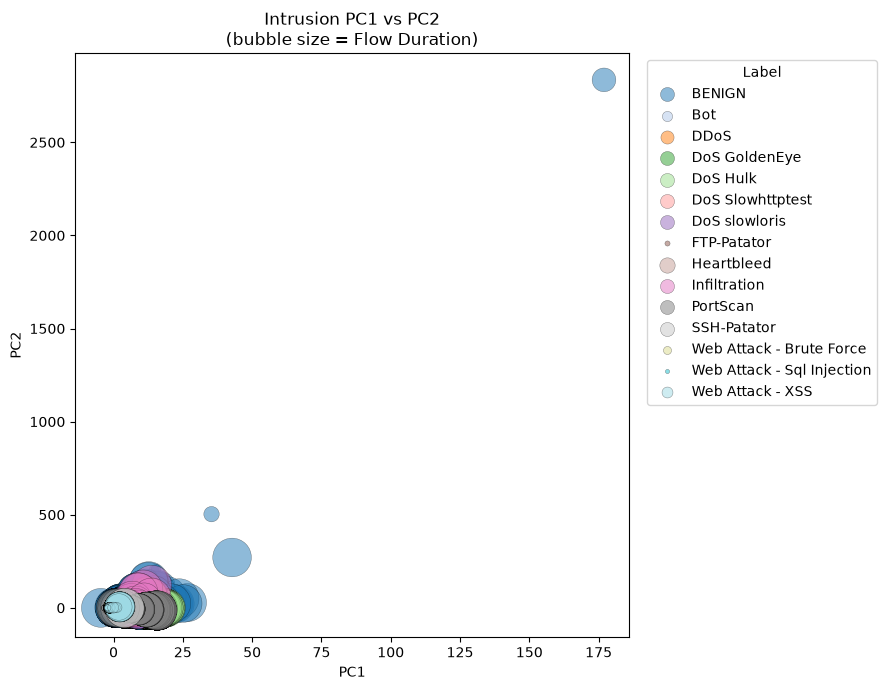

In [118]:
# Bubbleplot for Flow Duration
bubble_plot('PC1', 'PC2', 'Flow Duration', 'Intrusion PC1 vs PC2', 'intrusion_bubble_pc1_pc2_flowduration.png')

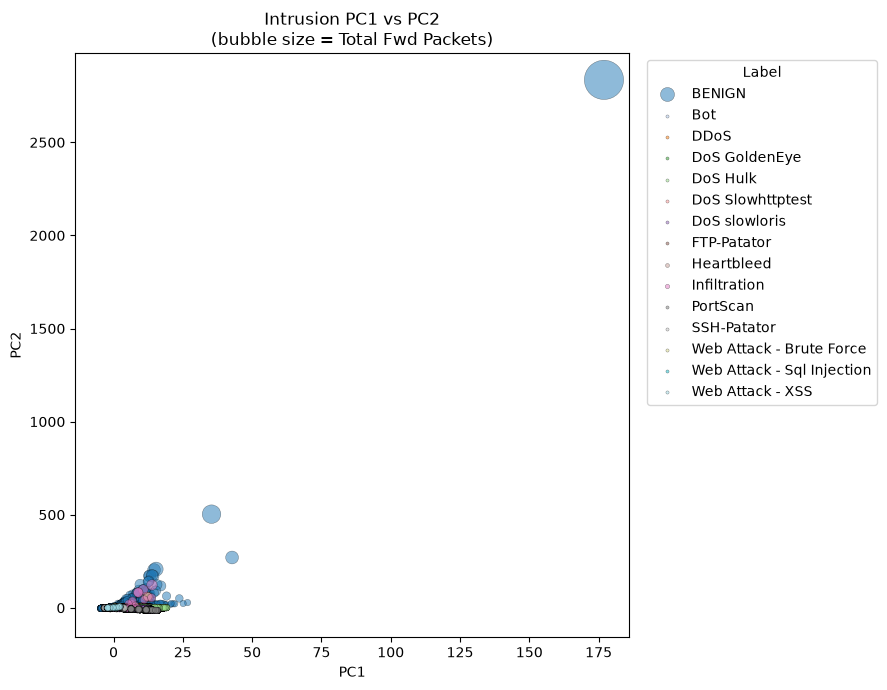

In [119]:
# Bubbleplot for Total Fwd Packets
bubble_plot('PC1', 'PC2', 'Total Fwd Packets', 'Intrusion PC1 vs PC2', 'intrusion_bubble_pc1_pc2_totalfwdpackets.png')

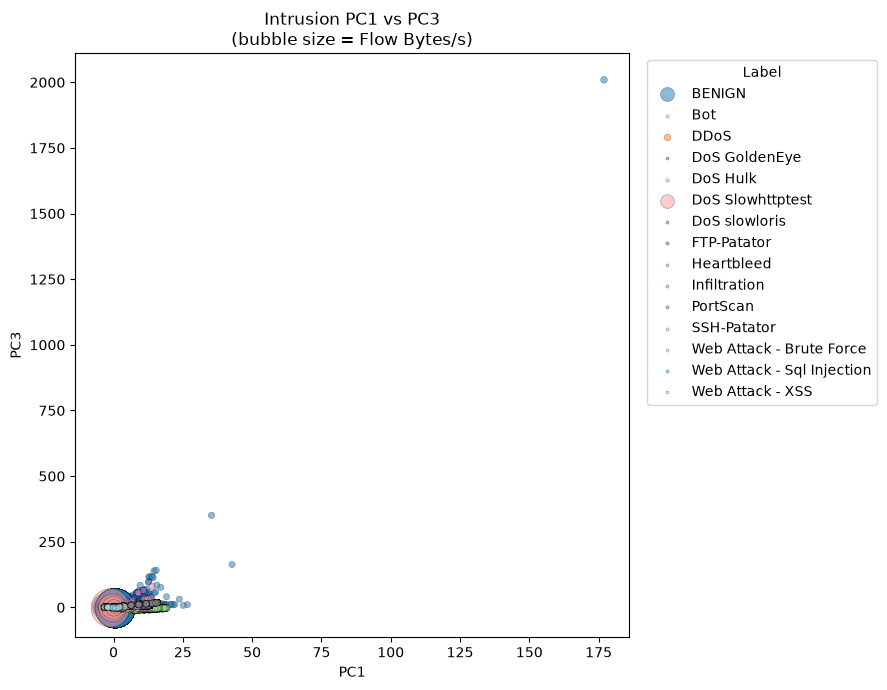

In [120]:
# Bubbleplot for Flow Bytes/s
bubble_plot('PC1', 'PC3', 'Flow Bytes/s', 'Intrusion PC1 vs PC3', 'intrusion_bubble_pc1_pc3_flowbytespersec.png')

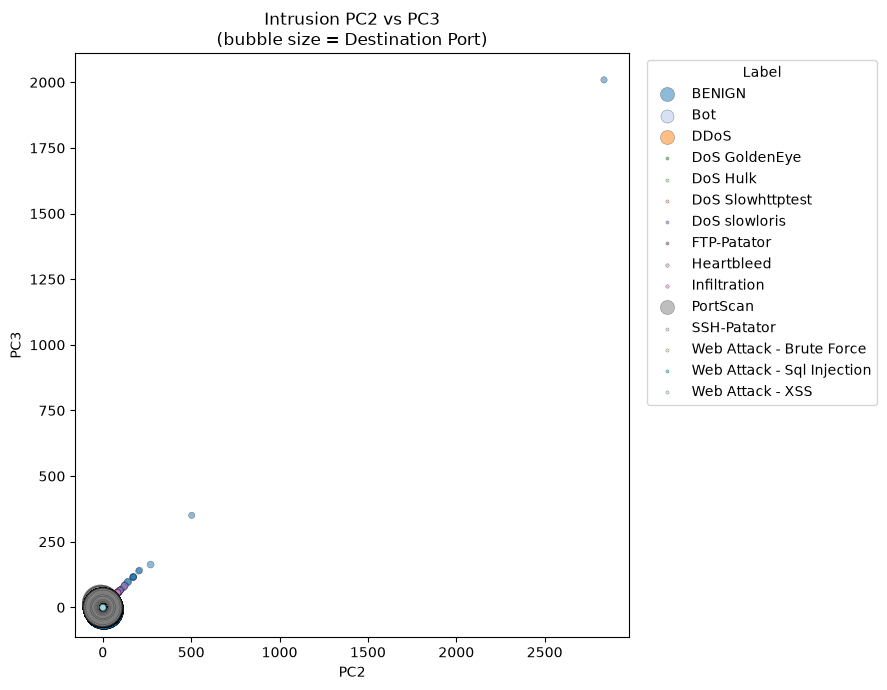

In [121]:
# Bubbleplot for Destination Port
bubble_plot('PC2', 'PC3', 'Destination Port', 'Intrusion PC2 vs PC3', 'intrusion_bubble_pc2_pc3_destinationport.png')

### Regression

In [122]:
# Regression

# Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (2014306, 69) Test shape: (503577, 69)


#### Linear Regression

##### General analysis

In [123]:
# Linear Regression Analysis

# Calculate the R^2 and RMSE
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

print(f"R^2: {r2_score(y_test, y_pred_lin):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_lin) ** 0.5:.4f}")

y_pred_lin_class = (y_pred_lin >= 0.5).astype(int)
print(f"Accuracy (0.5 threshold on linear output): {accuracy_score(y_test, y_pred_lin_class):.4f}")

R^2: 0.2114
RMSE: 1.9484
Accuracy (0.5 threshold on linear output): 0.5507


In [124]:
# Create Coefficient DataFrame & print
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.head(15)

,feature,coefficient
67,Idle Max,6.259306
40,Packet Length Mean,-3.256962
68,Idle Min,-3.040977
50,Average Packet Size,2.783631
39,Max Packet Length,2.730097
18,Flow IAT Max,-2.675764
24,Fwd IAT Min,2.056888
22,Fwd IAT Std,1.902637
10,Bwd Packet Length Max,-1.845629
45,PSH Flag Count,1.667651


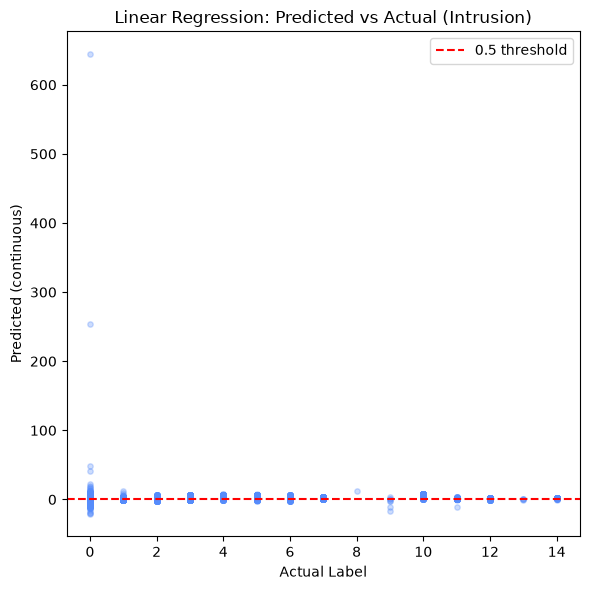

In [125]:
# Plot the Regression
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lin, alpha=0.3, s=15)
ax.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
ax.set_xlabel('Actual Label')
ax.set_ylabel('Predicted (continuous)')
ax.set_title('Linear Regression: Predicted vs Actual (Intrusion)')
ax.legend()
plt.tight_layout()
plt.show()

##### Feature-to-feature analysis

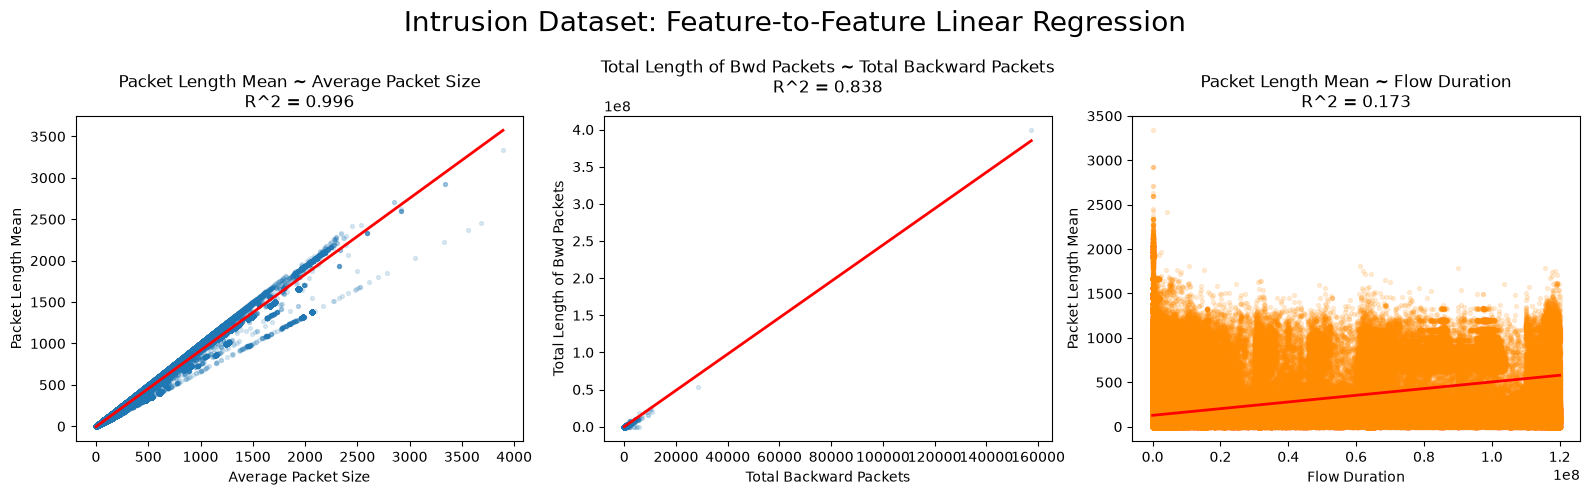

In [126]:
# Feature-to-feature regression plots (Intrusion)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('Average Packet Size', 'Packet Length Mean', axes[0]),
    ('Total Backward Packets', 'Total Length of Bwd Packets', axes[1]),
    ('Flow Duration', 'Packet Length Mean', axes[2]),  # unrelated, for contrast
]
colors = ['tab:blue', 'tab:blue', 'darkorange']

for (xcol, ycol, ax), color in zip(pairs, colors):
    x = intrusion_df[[xcol]]
    y = intrusion_df[ycol]
    X_tr, X_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=42)
    lr = LinearRegression().fit(X_tr, y_tr)
    r2 = r2_score(y_te, lr.predict(X_te))

    ax.scatter(x, y, alpha=0.15, s=8, color=color)
    xs = np.linspace(x.values.min(), x.values.max(), 100).reshape(-1, 1)
    ax.plot(xs, lr.predict(xs), color='red', linewidth=2)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{ycol} ~ {xcol}\nR^2 = {r2:.3f}", fontsize=12)

plt.suptitle("Intrusion Dataset: Feature-to-Feature Linear Regression", fontsize=20)
plt.tight_layout()
plt.show()

#### Logistic Regression

In [127]:
# Logistic Regression

# Setup
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)  # full (n_samples, 15) probability matrix

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC (macro, OvR): {roc_auc_score(y_test, y_proba_log, multi_class='ovr', average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_log, target_names=[
    'BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
    'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan',
    'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS'
]))

Accuracy: 0.9932
ROC-AUC (macro, OvR): 0.9917

                            precision    recall  f1-score   support

                    BENIGN       0.99      1.00      1.00    418467
                       Bot       0.71      0.03      0.05       390
                      DDoS       1.00      1.00      1.00     25599
             DoS GoldenEye       0.97      0.90      0.93      2056
                  DoS Hulk       0.99      0.98      0.98     34538
          DoS Slowhttptest       0.86      0.89      0.88      1046
             DoS slowloris       0.92      0.90      0.91      1077
               FTP-Patator       0.98      0.99      0.98      1186
                Heartbleed       0.33      1.00      0.50         1
              Infiltration       0.20      0.14      0.17         7
                  PortScan       0.97      0.99      0.98     18139
               SSH-Patator       0.99      0.92      0.95       643
  Web Attack - Brute Force       0.90      0.06      0.11       294


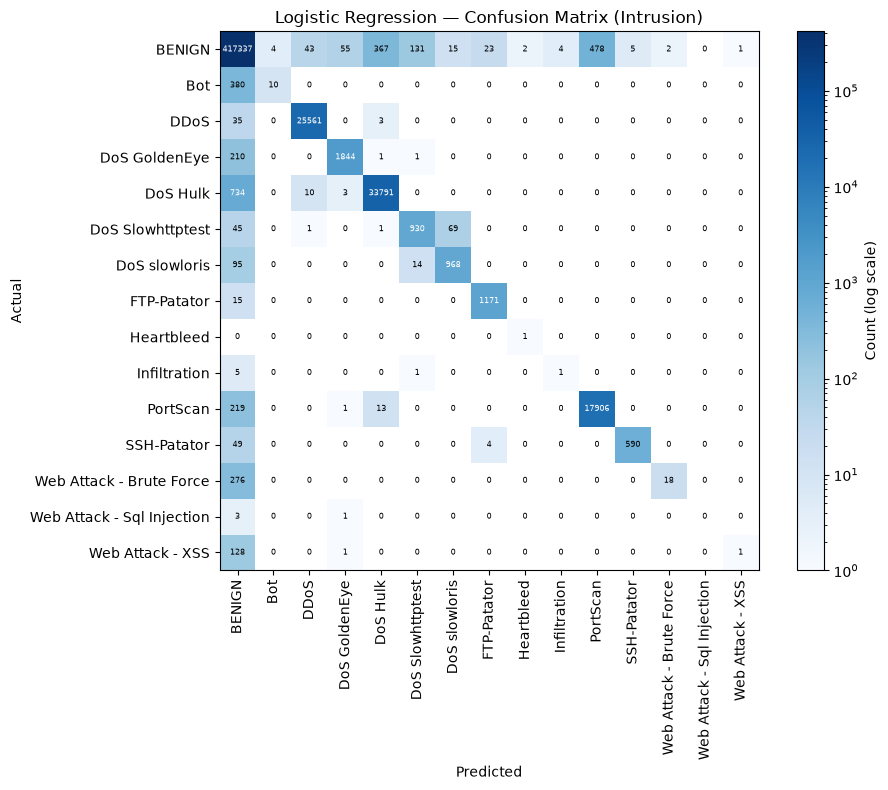

In [128]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)
n_classes = len(label_names)
class_names = [label_names[i] for i in range(n_classes)]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues', norm=LogNorm(vmin=1, vmax=cm.max()))

for i in range(n_classes):
    for j in range(n_classes):
        val = cm[i, j]
        # zero cells fall outside LogNorm's range and render as background, so just use black text there
        text_color = 'black' if val == 0 else ('white' if im.norm(val) > 0.5 else 'black')
        ax.text(j, i, val, ha='center', va='center', fontsize=6, color=text_color)

ax.set_xticks(range(n_classes)); ax.set_xticklabels(class_names, rotation=90)
ax.set_yticks(range(n_classes)); ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix (Intrusion)')
fig.colorbar(im, ax=ax, label='Count (log scale)')
plt.tight_layout()
plt.show()

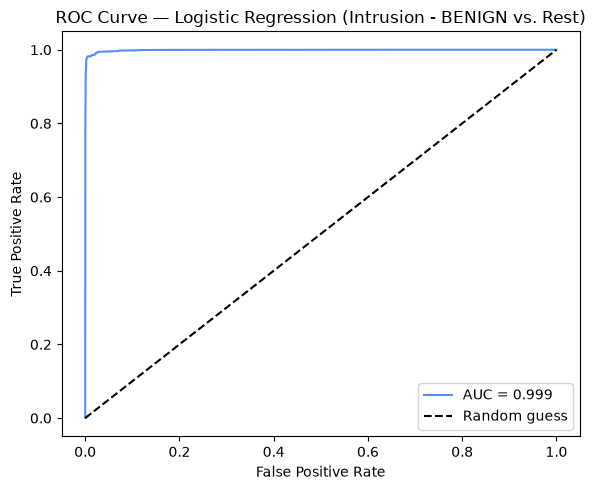

In [129]:
# ROC Curve

# BENIGN vs. Rest
benign_idx = 0  # index of 'BENIGN' in label_names / label_to_int

y_test_binary = (y_test != benign_idx).astype(int)                        # 1 = any attack, 0 = BENIGN
y_score_binary = 1 - log_reg.predict_proba(X_test_scaled)[:, benign_idx]  # P(not BENIGN)

fpr, tpr, _ = roc_curve(y_test_binary, y_score_binary)
auc = roc_auc_score(y_test_binary, y_score_binary)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression (Intrusion - BENIGN vs. Rest)')
ax.legend()
plt.tight_layout()
plt.show()

## Dataset 3: Misinformation

### Setup

In [130]:
# Load the dataset
misinformation_df = pd.read_csv("misinformation.csv", encoding="latin1", dtype=str)

# Drop unnamed index columns and clean up column names
misinformation_df = misinformation_df.loc[:, ~misinformation_df.columns.str.contains('^Unnamed')]
misinformation_df.columns = misinformation_df.columns.str.strip()

print(misinformation_df.shape)

(72134, 3)


In [131]:
# Print the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [132]:
# Normalize the Label column

# Where 1 = real, 0 = fake. Since they're already 0, 1, verify they are ints. 
print("Unique label values:", sorted(misinformation_df['label'].unique()))

misinformation_df['label'] = misinformation_df['label'].astype(int)
misinformation_df['label'].value_counts()

Unique label values: ['0', '1']


label
1    37106
0    35028
Name: count, dtype: int64

In [133]:
# Drop duplicate rows
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 8456 duplicate rows -> 63678 rows remaining


In [134]:
# Drop null & NaN values
before = len(misinformation_df)
misinformation_df = misinformation_df.dropna()
print(f"Dropped {before - len(misinformation_df)} rows with null/NaN values -> {len(misinformation_df)} rows remaining")

Dropped 557 rows with null/NaN values -> 63121 rows remaining


In [135]:
# Create numerical columns
def add_text_features(df, col, prefix):
    text = df[col].astype(str)
    words = text.str.split()

    df[f'{prefix}_word_count'] = words.str.len()
    df[f'{prefix}_char_count'] = text.str.len()
    df[f'{prefix}_avg_word_length'] = (
        df[f'{prefix}_char_count'] / df[f'{prefix}_word_count'].replace(0, np.nan)
    ).fillna(0)
    df[f'{prefix}_exclamation_count'] = text.str.count('!')
    df[f'{prefix}_question_count'] = text.str.count(r'\?')
    df[f'{prefix}_digit_count'] = text.str.count(r'\d')
    df[f'{prefix}_uppercase_word_count'] = words.apply(
        lambda ws: sum(1 for w in ws if w.isupper() and len(w) > 1)
    )
    return df

misinformation_df = add_text_features(misinformation_df, 'title', 'title')
misinformation_df = add_text_features(misinformation_df, 'text', 'text')

misinformation_df.filter(like='_count').head()

,title_word_count,title_char_count,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,18,130,0,0,6,7,871,5049,2,7,30,6
2,18,145,1,0,0,9,34,216,0,0,0,0
3,16,105,0,0,4,0,1321,8120,0,1,34,7
4,16,101,0,0,1,1,329,1932,0,0,70,16
5,13,78,1,0,0,1,244,1530,1,0,0,13


In [136]:
# Drop negative values
before = len(misinformation_df)
numeric_cols = misinformation_df.select_dtypes(include=[np.number]).columns
negative_mask = (misinformation_df[numeric_cols] < 0).any(axis=1)
misinformation_df = misinformation_df[~negative_mask]
print(f"Dropped {before - len(misinformation_df)} rows containing negative values -> {len(misinformation_df)} rows remaining")

Dropped 0 rows containing negative values -> 63121 rows remaining


In [137]:
# Drop non-numerical columns
non_numeric_cols = misinformation_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

misinformation_df = misinformation_df.drop(columns=non_numeric_cols)
print(misinformation_df.shape)

Dropping non-numeric columns: ['title', 'text']
(63121, 15)


In [138]:
# Drop perfectly correlated columns
corr_matrix = misinformation_df.drop(columns=['label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

misinformation_df = misinformation_df.drop(columns=perfectly_correlated)
print(misinformation_df.shape)

Dropping 0 columns with ~1.00 correlation to an earlier column:
[]
(63121, 15)


In [139]:
# Drop duplicate rows (post feature engineering)
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 48 duplicate rows -> 63073 rows remaining


In [140]:
# Print clean DataFrame
misinformation_df.head()

,label,title_word_count,title_char_count,title_avg_word_length,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,1,18,130,7.222222,0,0,6,7,871,5049,5.796785,2,7,30,6
2,1,18,145,8.055556,1,0,0,9,34,216,6.352941,0,0,0,0
3,0,16,105,6.562500,0,0,4,0,1321,8120,6.146858,0,1,34,7
4,1,16,101,6.312500,0,0,1,1,329,1932,5.872340,0,0,70,16
5,1,13,78,6.000000,1,0,0,1,244,1530,6.270492,1,0,0,13


In [141]:
# Sanity check
print("Any nulls left:", misinformation_df.isnull().values.any())
print("Any negatives left:", (misinformation_df < 0).values.any())
print("Any duplicate rows left:", misinformation_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in misinformation_df.dtypes))
print("\nFinal shape:", misinformation_df.shape)
print("\nLabel counts:")
print(misinformation_df['label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (63073, 15)

Label counts:
label
0    34780
1    28293
Name: count, dtype: int64


In [142]:
# Export cleaned data to CSV
misinformation_df.to_csv("misinformation_clean.csv", index=False)
print("Saved misinformation_clean.csv")

Saved misinformation_clean.csv


### Heatmaps

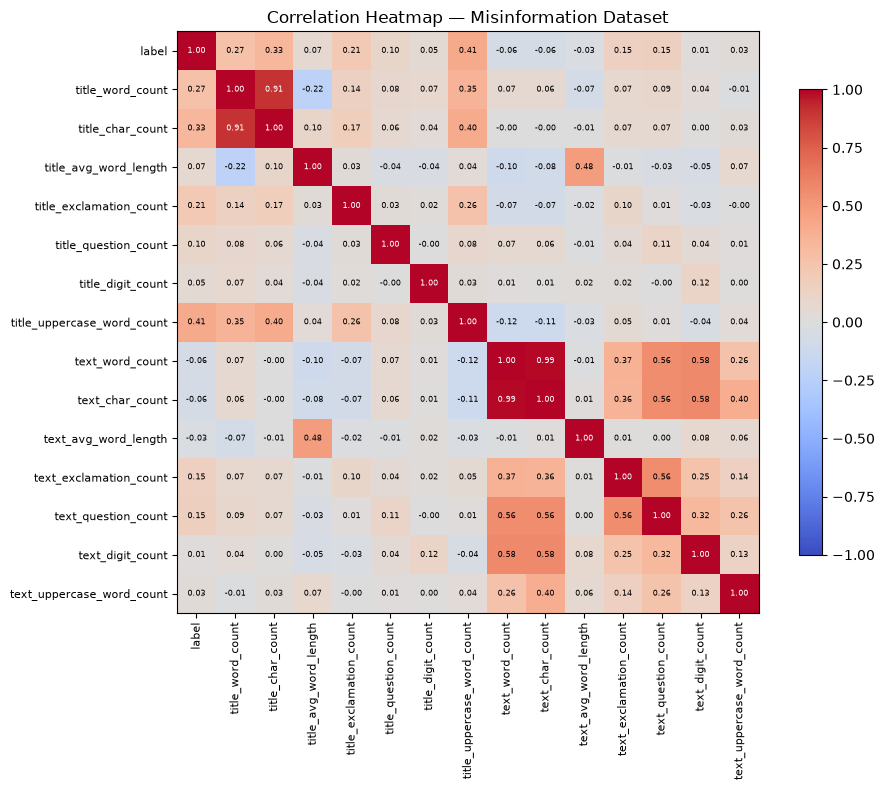

In [143]:
# Draw Heatmaps

# Correlation
corr = misinformation_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

# annotate cells with the correlation value (dataset is small enough to be readable)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=6,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Heatmap — Misinformation Dataset")
plt.tight_layout()
plt.show()

### Principal Component Analysis (PCA)

#### Projection onto first principal component

PC1 alone captures 23.4% of total variance

Per-feature reconstruction error (standardized space, lower = better represented by PC1):
text_char_count               0.1445
text_word_count               0.1695
text_question_count           0.4369
text_digit_count              0.5498
text_exclamation_count        0.6576
text_uppercase_word_count     0.8227
title_word_count              0.9769
title_question_count          0.9849
title_avg_word_length         0.9898
title_char_count              0.9908
title_digit_count             0.9971
title_uppercase_word_count    0.9985
title_exclamation_count       0.9993
text_avg_word_length          0.9999
dtype: float64


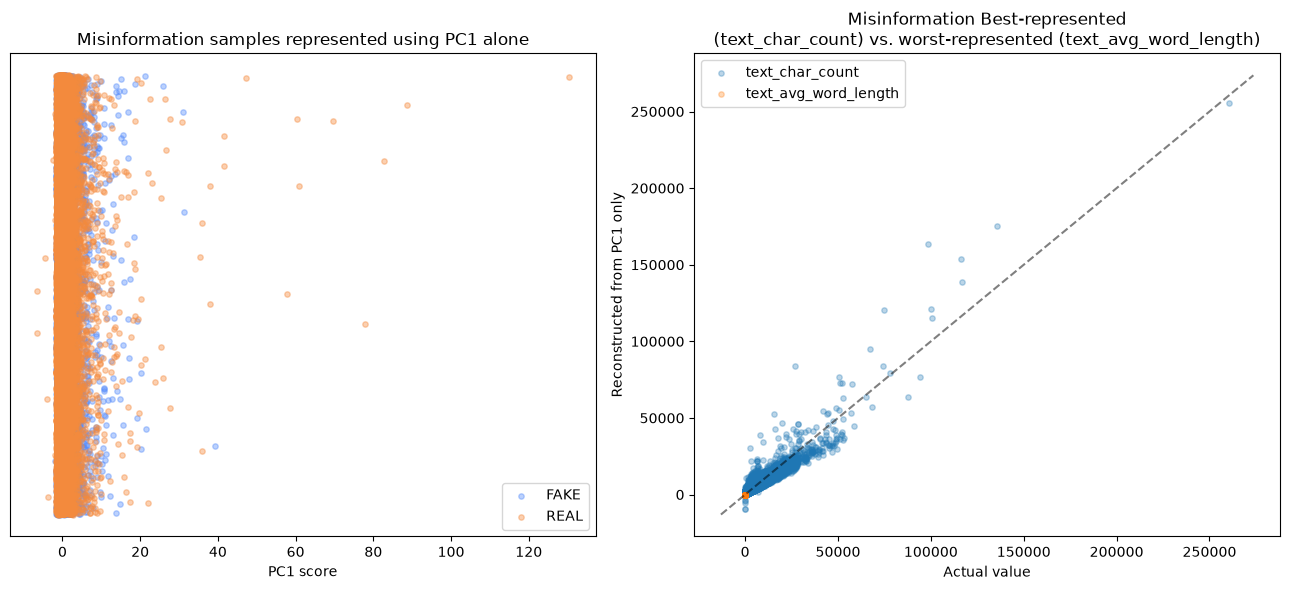

In [144]:
# Principal component analysis

# Representing the data using only PC1
X_pc1 = misinformation_df.drop(columns=['label'])
y_pc1 = misinformation_df['label']

scaler_pc1 = StandardScaler()
X_scaled_pc1 = scaler_pc1.fit_transform(X_pc1)

pca_pc1 = PCA()
pca_pc1.fit(X_scaled_pc1)

scores_pc1 = X_scaled_pc1 @ pca_pc1.components_[0]
X_scaled_reconstructed_pc1 = np.outer(scores_pc1, pca_pc1.components_[0])

var_explained_pc1 = pca_pc1.explained_variance_ratio_[0]
print(f"PC1 alone captures {var_explained_pc1:.1%} of total variance")

recon_mse_pc1 = pd.Series(((X_scaled_pc1 - X_scaled_reconstructed_pc1) ** 2).mean(axis=0), index=X_pc1.columns)
print("\nPer-feature reconstruction error (standardized space, lower = better represented by PC1):")
print(recon_mse_pc1.round(4).sort_values())

# Plot
label_names_pc1 = {0: 'FAKE', 1: 'REAL'}
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
rng = np.random.default_rng(0)
for lbl, name in label_names_pc1.items():
    mask = (y_pc1 == lbl).values
    ax.scatter(scores_pc1[mask], rng.uniform(-0.05, 0.05, mask.sum()), label=name, alpha=0.4, s=15)
ax.set_yticks([])
ax.set_xlabel('PC1 score')
ax.set_title('Misinformation samples represented using PC1 alone', fontsize=12)
ax.legend()

X_reconstructed_pc1 = scaler_pc1.inverse_transform(X_scaled_reconstructed_pc1)
best_feat, worst_feat = recon_mse_pc1.idxmin(), recon_mse_pc1.idxmax()
ax2 = axes[1]
for feat, color in [(best_feat, 'tab:blue'), (worst_feat, 'tab:orange')]:
    j = X_pc1.columns.get_loc(feat)
    ax2.scatter(X_pc1[feat], X_reconstructed_pc1[:, j], alpha=0.3, s=15, label=feat, color=color)
lims = ax2.get_xlim()
ax2.plot(lims, lims, 'k--', alpha=0.5)
ax2.set_xlabel('Actual value')
ax2.set_ylabel('Reconstructed from PC1 only')
ax2.set_title(f'Misinformation Best-represented\n({best_feat}) vs. worst-represented ({worst_feat})', fontsize=12)
ax2.legend()
plt.tight_layout()
plt.show()

#### Cumulative variance

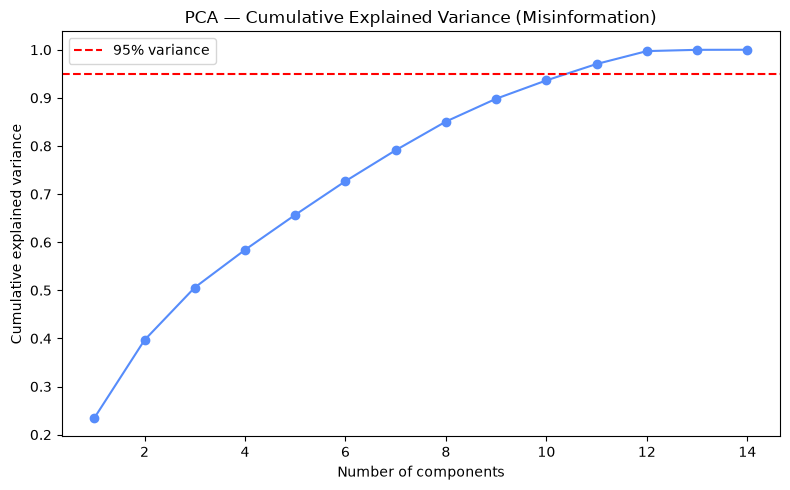

Components needed to explain 95% variance: 11 / 14


In [145]:
# Variance
X = misinformation_df.drop(columns=['label'])
y = misinformation_df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — Cumulative Explained Variance (Misinformation)')
ax.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Components needed to explain 95% variance: {n_components_95} / {X.shape[1]}")

### Bubbleplots

In [146]:
# Draw bubbleplots

# Setup: Using the first 3 principal components as plot axes (PC1/PC2/PC3), with bubble size mapped to a chosen raw feature and color mapped to `Label` (fake vs. real).
pcs = pca.transform(X_scaled)
pc_df = pd.DataFrame(pcs[:, :3], columns=['PC1', 'PC2', 'PC3'], index=X.index)

def scaled_size(series, low=20, high=800):
    s = (series - series.min()) / (series.max() - series.min())
    return s * (high - low) + low

label_names = {0: 'FAKE', 1: 'REAL'}
label_colors = {0: 'tab:red', 1: 'tab:blue'}

In [147]:
# Bubbleplot function
def bubble_plot(x_col, y_col, size_col, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = scaled_size(X[size_col])
    for lbl, color in label_colors.items():
        mask = (y == lbl)
        ax.scatter(pc_df.loc[mask, x_col], pc_df.loc[mask, y_col],
                   s=sizes[mask], c=color, alpha=0.5, edgecolors='k', linewidths=0.3,
                   label=label_names[lbl])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{title}\n(bubble size = {size_col})")
    ax.legend(title='Label', markerscale=0.5)
    plt.tight_layout()
    plt.show()

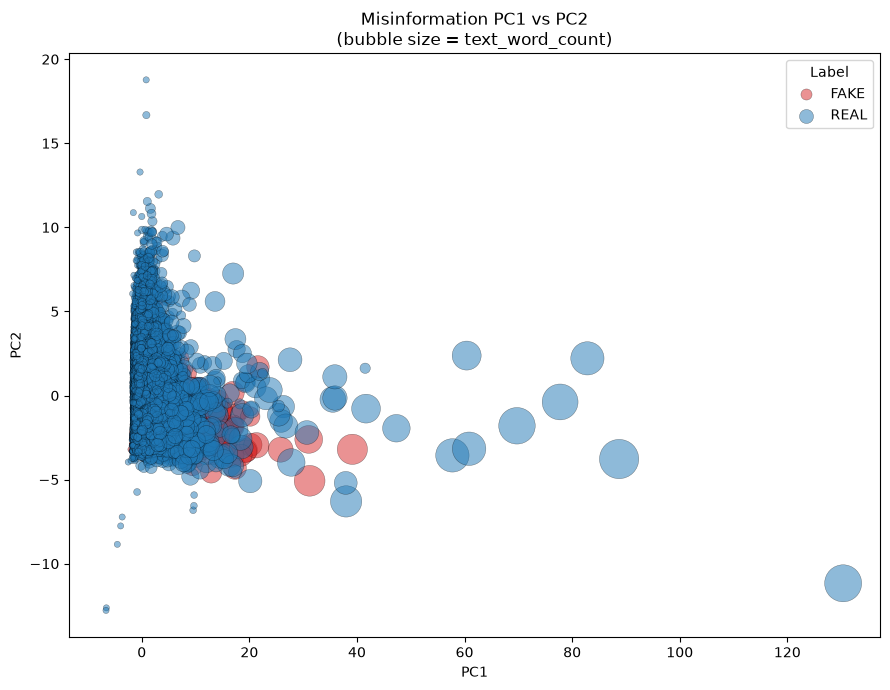

In [148]:
# Bubbleplot for Text Word Count
bubble_plot('PC1', 'PC2', 'text_word_count', 'Misinformation PC1 vs PC2', 'misinformation_bubble_pc1_pc2_textwordcount.png')

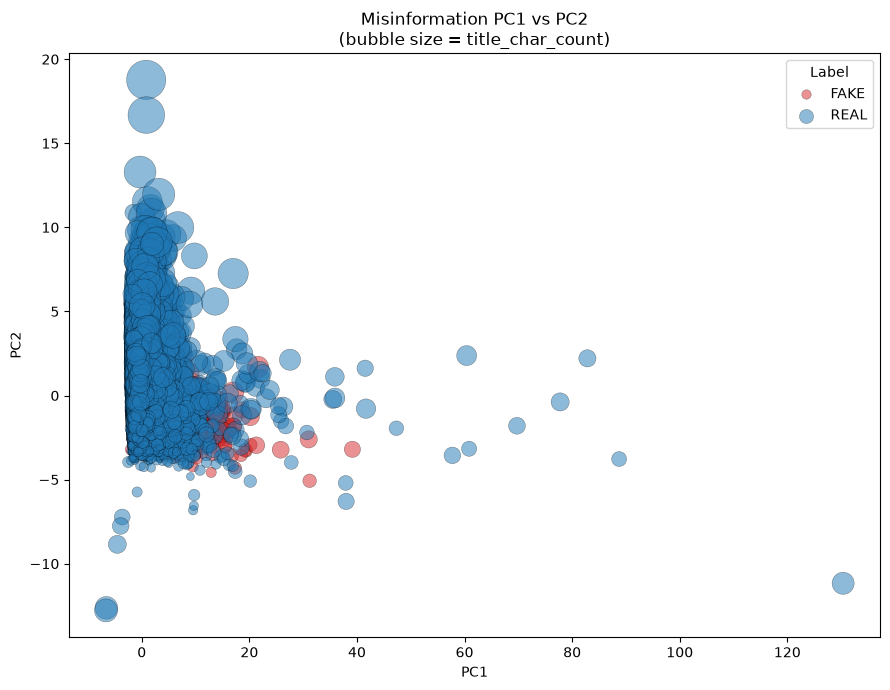

In [149]:
# Bubbleplot for Title Char Count
bubble_plot('PC1', 'PC2', 'title_char_count', 'Misinformation PC1 vs PC2', 'misinformation_bubble_pc1_pc2_titlecharcount.png')

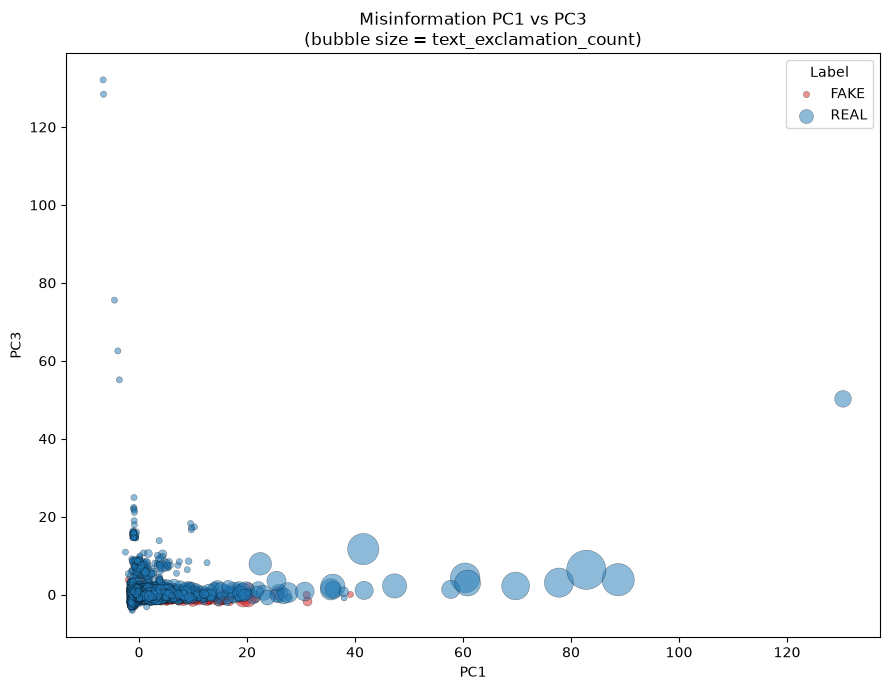

In [150]:
# Bubbleplot for Text Exclamation Count
bubble_plot('PC1', 'PC3', 'text_exclamation_count', 'Misinformation PC1 vs PC3', 'misinformation_bubble_pc1_pc3_exclamation.png')

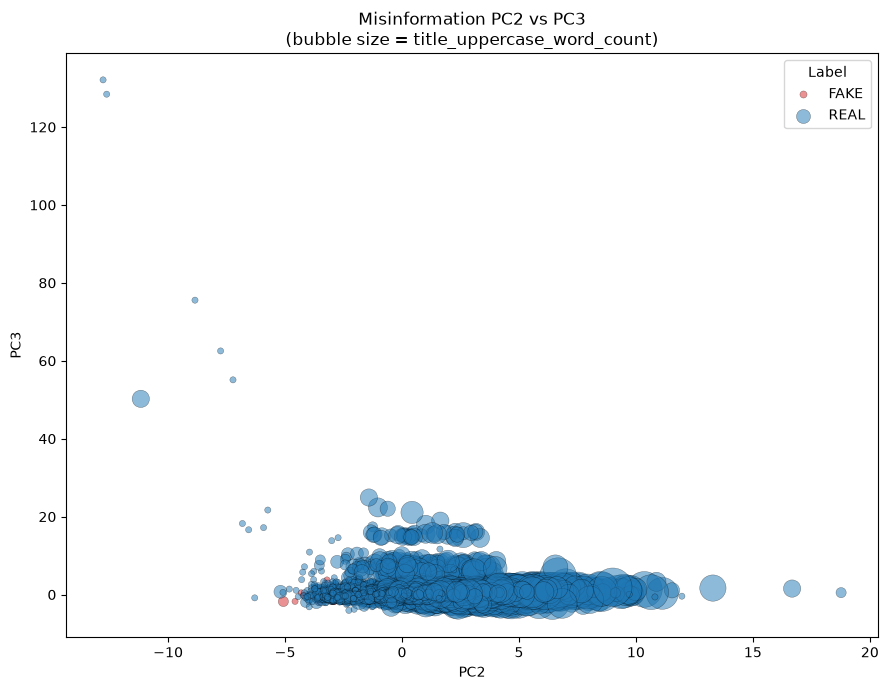

In [151]:
# Bubbleplot for Title Uppercase Word Count
bubble_plot('PC2', 'PC3', 'title_uppercase_word_count', 'Misinformation PC2 vs PC3', 'misinformation_bubble_pc2_pc3_uppercase.png')

### Regression

In [152]:
# Regression

# Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (50458, 14) Test shape: (12615, 14)


#### Linear Regression

In [153]:
# Linear Regression Analysis

# Calculate teh R^2 and RMSE
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

print(f"R^2: {r2_score(y_test, y_pred_lin):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_lin) ** 0.5:.4f}")

y_pred_lin_class = (y_pred_lin >= 0.5).astype(int)
print(f"Accuracy (0.5 threshold on linear output): {accuracy_score(y_test, y_pred_lin_class):.4f}")

R^2: 0.2662
RMSE: 0.4260
Accuracy (0.5 threshold on linear output): 0.7698


In [154]:
# Create Coefficient DataFrame & print
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.head(15)

,feature,coefficient
8,text_char_count,-0.196444
6,title_uppercase_word_count,0.142908
1,title_char_count,0.137344
7,text_word_count,0.107960
11,text_question_count,0.082704
0,title_word_count,-0.056198
3,title_exclamation_count,0.043119
12,text_digit_count,0.028593
4,title_question_count,0.027402
10,text_exclamation_count,0.026943


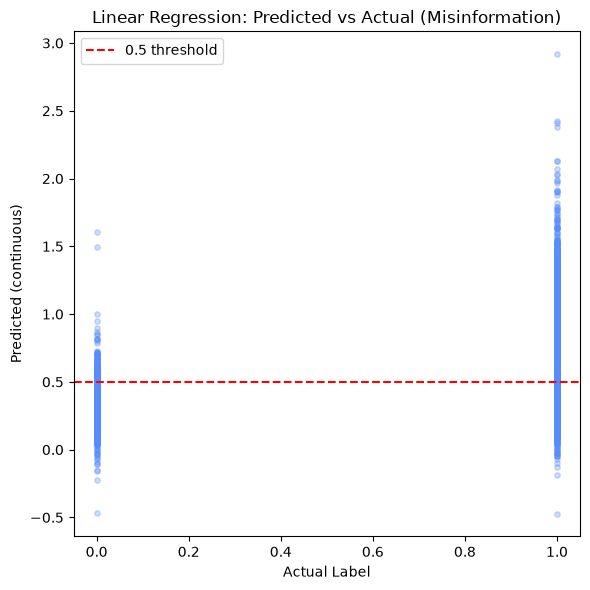

In [155]:
# Plot the Regression
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lin, alpha=0.3, s=15)
ax.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
ax.set_xlabel('Actual Label')
ax.set_ylabel('Predicted (continuous)')
ax.set_title('Linear Regression: Predicted vs Actual (Misinformation)')
ax.legend()
plt.tight_layout()
plt.show()

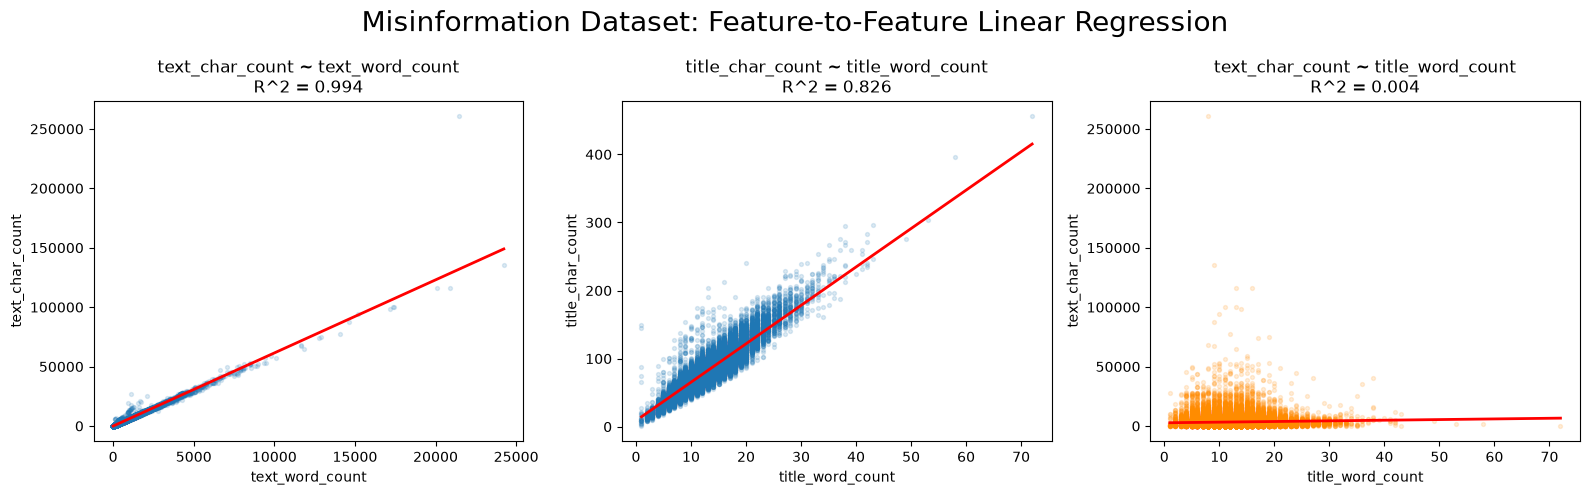

In [156]:
# Feature-to-feature regression plots (Misinformation)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('text_word_count', 'text_char_count', axes[0]),
    ('title_word_count', 'title_char_count', axes[1]),
    ('title_word_count', 'text_char_count', axes[2]),  # unrelated, for contrast
]
colors = ['tab:blue', 'tab:blue', 'darkorange']

for (xcol, ycol, ax), color in zip(pairs, colors):
    x = misinformation_df[[xcol]]
    y = misinformation_df[ycol]
    X_tr, X_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=42)
    lr = LinearRegression().fit(X_tr, y_tr)
    r2 = r2_score(y_te, lr.predict(X_te))

    ax.scatter(x, y, alpha=0.15, s=8, color=color)
    xs = np.linspace(x.values.min(), x.values.max(), 100).reshape(-1, 1)
    ax.plot(xs, lr.predict(xs), color='red', linewidth=2)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{ycol} ~ {xcol}\nR^2 = {r2:.3f}", fontsize=12)

plt.suptitle("Misinformation Dataset: Feature-to-Feature Linear Regression", fontsize=20)
plt.tight_layout()
plt.show()

#### Logistic Regression

In [157]:
# Logistic Regression

# Setup
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log):.4f}")
print()
print(classification_report(y_test, y_pred_log, target_names=['FAKE', 'REAL']))

Accuracy: 0.7829
ROC-AUC: 0.8252

              precision    recall  f1-score   support

        FAKE       0.75      0.91      0.82      6956
        REAL       0.85      0.63      0.72      5659

    accuracy                           0.78     12615
   macro avg       0.80      0.77      0.77     12615
weighted avg       0.79      0.78      0.78     12615



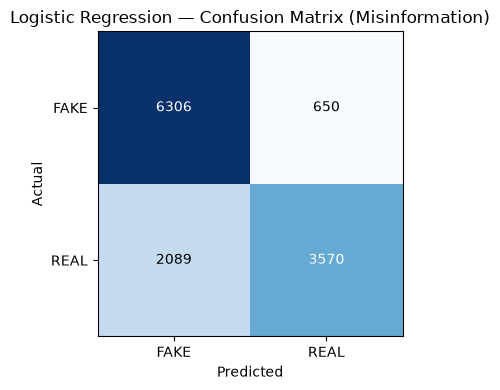

In [158]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['FAKE', 'REAL'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['FAKE', 'REAL'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix (Misinformation)')
plt.tight_layout()
plt.show()

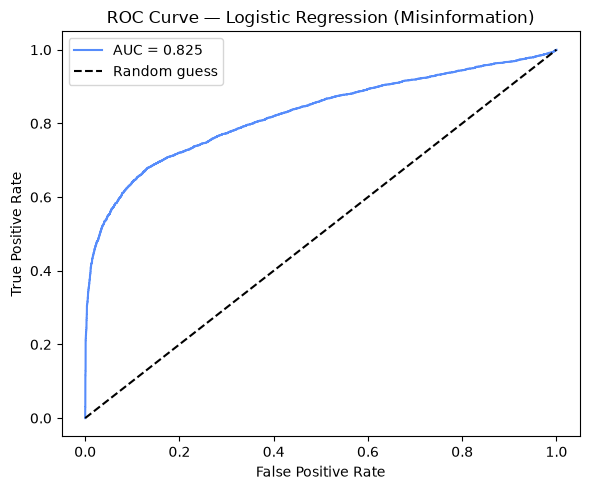

In [159]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_log)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_log):.3f}")
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression (Misinformation)')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

**Ransomware / malware traffic dataset:**
Yes to both. This is CICFlowMeter-style network flow data — packet counts, byte counts, inter-arrival times, flags — the standard format for traffic-based malware detection, so the shape and features are unsurprising. Combining the ransomware and benign CSVs and cleaning them (dropping 0 duplicate rows, 0 null/NaN rows, 27 rows with genuinely invalid negative values, and 4 non-numeric identifier columns) leaves 18,204 flows across 73 features, split roughly 56% ransomware (10,159) to 44% benign (8,045) — a reasonably balanced dataset, not the kind of 90/10 imbalance that would make accuracy misleading. That said, the models built on it aren't strong: logistic regression reaches only 59.4% accuracy and a 0.643 ROC-AUC, with recall of just 34% on BENIGN versus 79% on RANSOMWARE, and linear regression explains almost none of the variance (R²=0.048). The data are clean and usable, but these 72 flow-level features only weakly separate this particular ransomware family from benign traffic on their own — additional features, more samples, or a non-linear classifier (e.g., random forest) would likely be needed before trusting this for real detection.

**Intrusion dataset:**
Same CICFlowMeter schema as ransomware, so no surprises in shape. The pipeline runs cleanly end-to-end: 2,830,743 raw rows → 2,522,362 after dedup → 2,520,798 after dropping 1,564 null/NaN rows → 2,517,883 after the negative-value filter (now correctly excluding Init_Win_bytes_forward/Init_Win_bytes_backward, whose -1 is a legitimate "no window observed" sentinel, not invalid data) → same 2,517,883 rows × 70 columns after dropping the 9 perfectly-correlated columns. That fix nearly doubled the retained data (1,302,309 → 2,517,883 rows), with the extra volume landing disproportionately on BENIGN (940K→2.09M), DDoS (81K→128K), and DoS GoldenEye (7.7K→10.3K) — the rarest classes (Heartbleed, Web Attack - Sql Injection, Infiltration) barely changed at all, so class imbalance is actually more pronounced now, not less. Model performance holds up well: Logistic Regression reaches 99.32% accuracy and a macro OvR AUC of 0.992 (down slightly from the pre-fix 0.996, which was inflated by training on a smaller, differently-shaped sample). Per-class recall is mostly stable or improved — DoS Slowhttptest (0.73→0.89) and DoS slowloris (0.86→0.90) both got better with more data — but Infiltration recall fell sharply (0.67→0.14); with only 7 test-set samples this is noise from a tiny class, not a real regression. The same sparse, low-signal classes remain the weak spot: Bot (0.03), Web Attack - Brute Force (0.06), Web Attack - XSS (0.01), and Web Attack - Sql Injection (0.00) are still essentially undetected, keeping macro-avg F1 (0.63) well below weighted-avg F1 (0.99). Honest read: fixing the sentinel-column bug didn't just correct a bookkeeping error — it changed which features matter (see below) and confirmed the imbalance problem is real and slightly worse than the buggy version suggested, reinforcing that the handful of severely under-represented attack types need oversampling, class weighting, or dedicated detection before the model can be trusted on them.

**Misinformation dataset:**
The dataset itself remains well-behaved and usable: 63,073 cleaned rows with a reasonable 55/45 fake-real split (34,780 vs. 28,293), no need to source new data. The counter-intuitive result from earlier analysis still holds: `title_uppercase_word_count` correlates +0.41 with label (1 = real), meaning *real* articles use more all-caps words in their titles than fake ones do (most likely acronyms like "U.S." or "FBI" rather than sensational emphasis) — so the naive "sensational language = fake" story doesn't hold cleanly here. Collapsing full articles down to 14 count-based features also means many distinct articles land on identical feature vectors, which is why a duplicate-removal pass after feature engineering was needed (48 rows dropped). 78.3% logistic regression accuracy (ROC-AUC 0.825) is a reasonable ceiling for this coarse, count-based feature set — not a sign of bad data.

Do you see any outliers? (Data points that are far from the rest of the data).

**Ransomware / malware traffic dataset:**
Yes, clearly visible in the PCA scatter plots. In PC1 vs. PC2, the bulk of flows sit within roughly ±10 of the origin, but one point sits far out at about (PC1≈51, PC2≈−38), with several others trailing off between PC1≈20–35 and PC2≈−10 to −24. In PC1 vs. PC3, one ransomware-labeled flow is dramatically isolated at about (PC1≈51, PC3≈160), and two benign flows sit well outside the main cloud around (27, 83) and (21, 60). This pattern is consistent with a small number of unusually large or long-lived flows — heavy-tailed byte/packet/duration distributions are normal for network traffic — but they're extreme enough to dominate a linear model's coefficients if left untreated, so robust scaling or winsorizing is worth considering before regression.

**Intrusion dataset:**
Yes, and more extreme than the other two datasets — one single point dominates the PCA structure. Across all ~2.57M cleaned flows, one BENIGN-labeled row sits at PC3≈476, roughly 2.5x further out than the next most extreme point (PC3≈192). PC1 and PC2 show the same heavy-tailed pattern on a smaller scale — PC1 reaches as high as ≈125, PC2 as low as ≈−159 — but nothing else approaches the PC3 extreme. This is consistent with a small number of unusually long-lived or high-volume benign flows (heavy-tailed byte/packet/duration distributions are normal for network traffic), and everything else clusters tightly near the origin, the same profile seen in the ransomware set given the shared CICFlowMeter schema. A point this dominant is worth inspecting directly — it's extreme enough to single-handedly skew variance calculations and any linear model's coefficients, and is a strong candidate for winsorizing or removal before it's trusted in PCA-based plots or regression.

**Misinformation dataset:**
Yes, and visually even more pronounced than the ransomware set. In the PC2/PC3 bubble plot, the bulk of articles cluster near PC3≈0, but a few real-labeled articles sit dramatically apart — as high as PC3≈130, 128, 76, 63, and 55. These are almost certainly very long articles, ALL-CAPS press releases, or scraped pages with unusual formatting, and they're far enough from the rest of the distribution to be worth inspecting individually before trusting a linear model built on this feature set.

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

**Ransomware / malware dataset:**
Not really. PC1 alone explains only 22.1% of the variance, and it takes 25 of the 72 features to reach 95% cumulative variance. A one- or two-component summary would lose most of the signal — even after removing redundant/duplicate columns, the remaining features capture genuinely distinct aspects of a flow (timing, size, flags) rather than a few redundant measurements in disguise.

**Intrusion dataset:**
It's very similar to the malware/ransomware dataset, and the numbers land almost identically. PC1 explains about 23.7% of variance, PC1+PC2 together about 34%, and it takes 24 of the 69 remaining features to reach 95% cumulative variance — essentially the same profile as the ransomware dataset, which makes sense since both share the same CICFlowMeter feature schema. No meaningful low-dimensional shortcut here either; the timing, size, and flag-based features are each capturing something the others aren't.

**Misinformation dataset:**
Also not much reduction available. PC1 explains about 23% of variance, PC1+PC2 about 40%, and it takes 11 of the 14 features to reach 95% cumulative variance. These engineered features are already fairly non-redundant — word count, character count, punctuation, and capitalization each capture a different aspect of the text — so there isn't much of a low-dimensional shortcut here either.

Try using your correlation information from previous weeks to help choose features for linear regression.

**Ransomware / malware dataset:**
Yes — this is exactly what the "Drop perfectly correlated columns" step does, right before the sanity check. Using the correlation matrix, any column with a correlation of 1.00 to an earlier-appearing column was dropped, keeping only the first of each pair. Eight columns were removed this way:

- `Subflow Fwd Packets` (r = 1.00 with `Total Fwd Packets`, which was kept)
- `Subflow Bwd Packets` (r = 1.00 with `Total Backward Packets`, kept)
- `Subflow Fwd Bytes` (r = 1.00 with `Total Length of Fwd Packets`, kept)
- `Subflow Bwd Bytes` (r = 1.00 with `Total Length of Bwd Packets`, kept)
- `Avg Fwd Segment Size` (r = 1.00 with `Fwd Packet Length Mean`, kept)
- `Avg Bwd Segment Size` (r = 1.00 with `Bwd Packet Length Mean`, kept)
- `SYN Flag Count` (r = 1.00 with `Fwd PSH Flags`, kept)
- `Fwd Header Length.1` (r = 1.00 with `Fwd Header Length`, kept — this one is a literal duplicate column in the source CICFlowMeter CSVs, not just a statistical coincidence)

The "drop perfectly correlated columns" step removes 8 columns with correlation ≥0.999 to an earlier column: Subflow Fwd Packets, Subflow Bwd Packets, Subflow Fwd Bytes, Subflow Bwd Bytes, Avg Fwd Segment Size, Avg Bwd Segment Size, SYN Flag Count, and Fwd Header Length.1. Most of these are definitional duplicates — subflow counts equal flow totals when a flow has one subflow (the CICFlowMeter default), and "average segment size" is defined identically to mean packet length — so dropping them avoids unstable, arbitrarily-split OLS coefficients without losing information. Beyond that, though, correlation with Label itself is weak across the board: the strongest individual feature is Fwd PSH Flags at r≈0.093, followed by Fwd IAT Max (0.089) and Fwd IAT Mean (0.079), with everything else under 0.075. That weak correlation structure is a useful early signal that a linear model won't fit this data well, which matches the low R² observed — no small set of features carries strong linear signal about the label, so feature selection by correlation mainly helps here by removing redundancy, not by identifying a few standout predictors.

**Intrusion dataset:**
Yes, and the result is essentially identical to the ransomware dataset — expected, since both share the same CICFlowMeter schema. The same threshold (r ≥ 0.999) drops the same 9 columns as before (Subflow Fwd Packets, Subflow Bwd Packets, Subflow Fwd Bytes, Subflow Bwd Bytes, Avg Fwd Segment Size, Avg Bwd Segment Size, SYN Flag Count, Fwd Header Length.1, plus CWE Flag Count) — that part of the pipeline was unaffected by the sentinel fix. What did change is which raw features correlate best with Label: previously min_seg_size_forward topped the list at r≈0.25; with the sentinel rows restored, it drops to r≈0.15 and 20th place, and timing/size features now lead instead — Fwd IAT Std (r≈0.30), Idle Mean (r≈0.28), and Bwd Packet Length Std (r≈0.28). This makes sense: the earlier ranking was partly an artifact of a smaller, less representative sample; with nearly double the rows and the Init_Win_bytes columns' full value range restored, the correlation structure settles on flow-timing and packet-size features rather than the window-size feature that was standing in for them.

Here's the full column inventory for the Intrusion dataset's correlated-column drop step, in the same format as the ransomware section.

Dropped (9 columns, r ≥ 0.999 with an earlier column):

- `Subflow Fwd Packets` (r = 1.00 with `Total Fwd Packets`, kept)
- `Subflow Bwd Packets` (r = 1.00 with `Total Backward Packets`, kept)
- `Subflow Fwd Bytes` (r = 1.00 with `Total Length of Fwd Packets`, kept)
- `Subflow Bwd Bytes` (r = 1.00 with `Total Length of Bwd Packets`, kept)
- `Avg Fwd Segment Size` (r = 1.00 with `Fwd Packet Length Mean`, kept)
- `Avg Bwd Segment Size` (r = 1.00 with `Bwd Packet Length Mean`, kept)
- `SYN Flag Count` (r = 1.00 with `Fwd PSH Flags`, kept)
- `Fwd Header Length.1` (r = 1.00 with `Fwd Header Length`, kept — a literal duplicate column in the source CICFlowMeter CSVs)
- `CWE Flag Count` (r = 1.00 with `ECE Flag Count`, kept) — the one column not seen in the ransomware set; attack traffic here exercises those flags jointly in a way ransomware/benign traffic didn't

**Misinformation dataset:**
No columns were dropped by the strict 1.00 threshold used in this notebook (correlation ≥ 0.999) — the "Drop perfectly correlated columns" cell found zero qualifying pairs. But the correlation heatmap shows two near-duplicate pairs worth flagging even though they didn't meet the cutoff: `title_word_count` vs. `title_char_count` (r = 0.91) and `text_word_count` vs. `text_char_count` (r = 0.99). These aren't coincidental either — word count and character count measure almost the same underlying thing, since longer text has both more words and more characters. A looser feature-selection threshold (e.g. 0.95 instead of 0.999) would likely drop one from each pair too. They were kept here because this notebook's redundancy check was deliberately set at the 1.00 level to catch exact/definitional duplicates, not merely highly correlated features.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

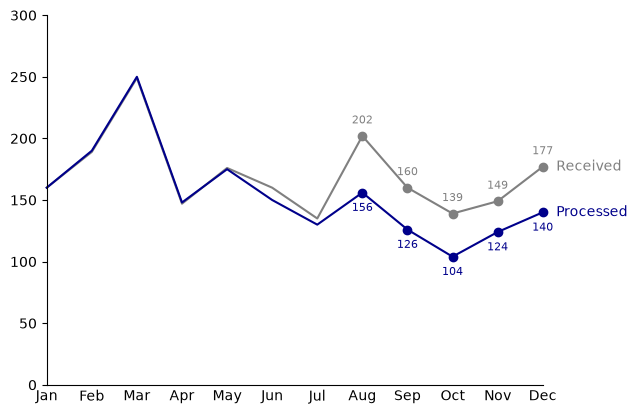

In [160]:
# Multiple Line Graph (Figure 5.8 on pg. 143)

# Data
x = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
y1 = [160, 189, 249, 147, 176, 160, 135, 202, 160, 139, 149, 177]
y2 = [160, 190, 250, 148, 175, 150, 130, 156, 126, 104, 124, 140]

# Use subplots to easily access the axes (ax) object
fig, ax = plt.subplots()

# Plotting multiple lines
line1, = plt.plot(x, y1, label='', color='gray', linestyle='-', marker='o', markevery=[7, 8, 9, 10, 11])
line2, = plt.plot(x, y2, label='', color='darkblue', linestyle='-', marker='o', markevery=[7, 8, 9, 10, 11])

# Prevent last marker from being cut in half
line1.set_clip_on(False)
line2.set_clip_on(False)

# Use the numeric index position (len(x) - 1) instead of the string name
last_index = len(x) - 1

# Force x-axis to start on y-axis and stop immediately after Dec
ax.set_xlim(left=0, right=last_index)

# Remove x-axis ticks
ax.tick_params(axis='x', length=0)

# Force y-axis to start at 0
ax.set_ylim(bottom=0)
ax.set_ylim(top=300)

ax.text(last_index + 0.3, y1[-1], 'Received', color='gray', va='center', ha='left', clip_on=False)
ax.text(last_index + 0.3, y2[-1], 'Processed', color='darkblue', va='center', ha='left', clip_on=False)

for i in range(7, len(x)):
    ax.text(i, y1[i] + 8, str(y1[i]), color='gray', ha='center', va='bottom', fontsize=8)
    ax.text(i, y2[i] - 8, str(y2[i]), color='darkblue', ha='center', va='top', fontsize=8)

# Customizations
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show plot
plt.show()